# Load Data

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# Load dataset
dataset = fetch_ucirepo(id=967)
df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

In [ ]:
X = df.drop(columns=['label'])
y = df[['label']]

# fixing types
binary_cols = [col for col in X.columns
               if set(X[col].dropna().unique()).issubset({0, 1})]

df[binary_cols] = df[binary_cols].astype('category')
df['label'] = df['label'].astype('category')

df

,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.000000,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.000000,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.000000,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.000000,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.000000,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235790,https://www.skincareliving.com,29,www.skincareliving.com,22,0,com,100.000000,1.000000,0.522907,0.058739,...,1,0,1,51,7,21,187,2,191,1
235791,https://www.winchester.gov.uk,28,www.winchester.gov.uk,21,0,uk,100.000000,0.785714,0.028555,0.053834,...,1,0,0,50,1,7,88,0,31,1
235792,https://www.nononsensedesign.be,30,www.nononsensedesign.be,23,0,be,100.000000,1.000000,0.003319,0.063093,...,0,0,1,27,10,30,58,2,67,1
235793,https://patient-cell-40f5.updatedlogmylogin.wo...,55,patient-cell-40f5.updatedlogmylogin.workers.dev,47,0,dev,28.157537,0.465116,0.000961,0.050211,...,0,0,0,0,0,3,0,0,0,0


In [ ]:
numeric_df = X.select_dtypes(include=np.number)
categorical_df = X.select_dtypes(include='category') #### NOTICE: categorical_df is built from X only ----> for label use y!!!!!

# Line Plot

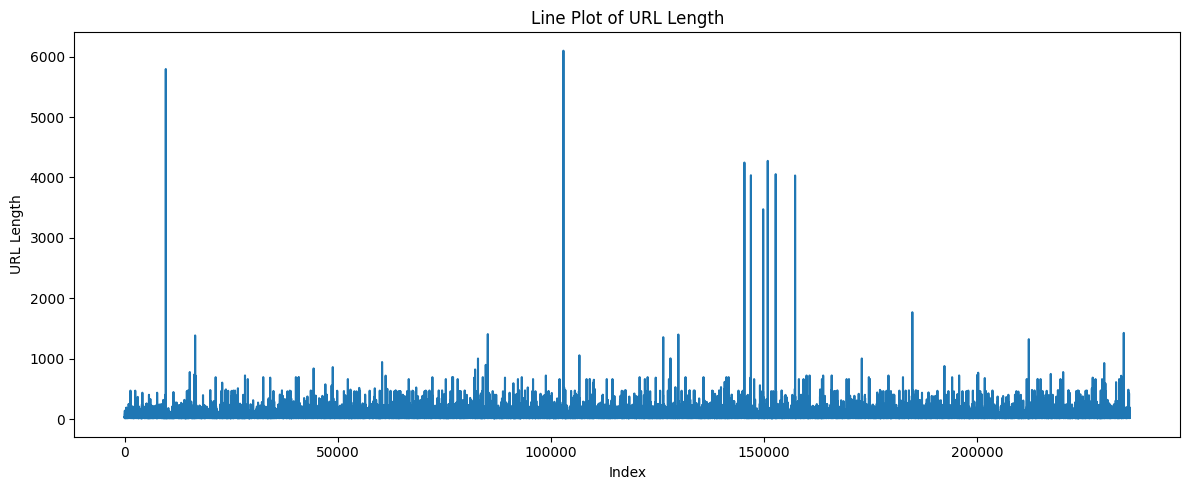

In [ ]:
# Line plot for single feature (URL Length)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df['URLLength'])
plt.title("Line Plot of URL Length")
plt.xlabel("Index")
plt.ylabel("URL Length")
plt.tight_layout()
plt.show()

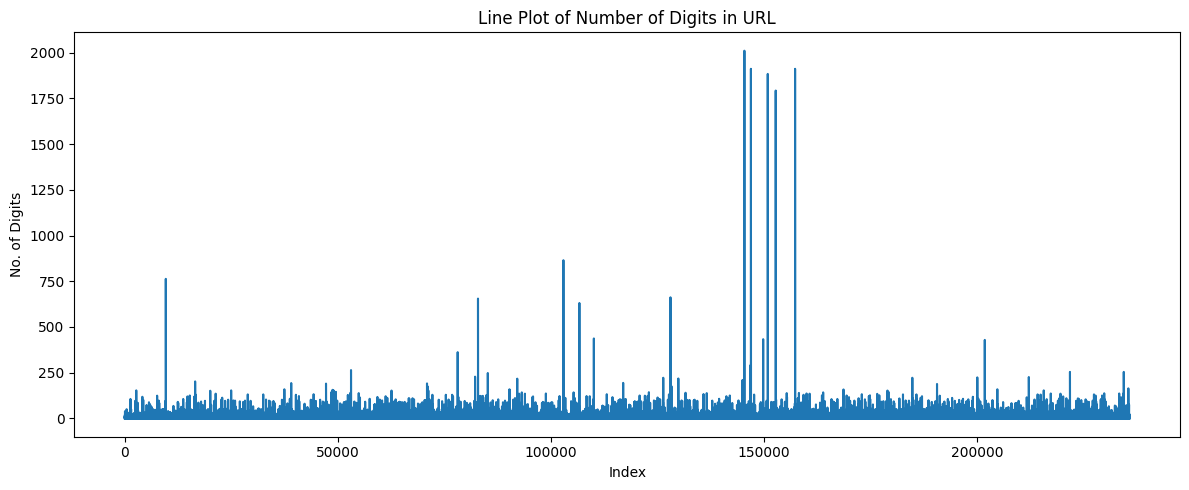

In [ ]:
# Line plot for single feature (Number of Digits)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df['NoOfDegitsInURL'])
plt.title("Line Plot of Number of Digits in URL")
plt.xlabel("Index")
plt.ylabel("No. of Digits")
plt.tight_layout()
plt.show()

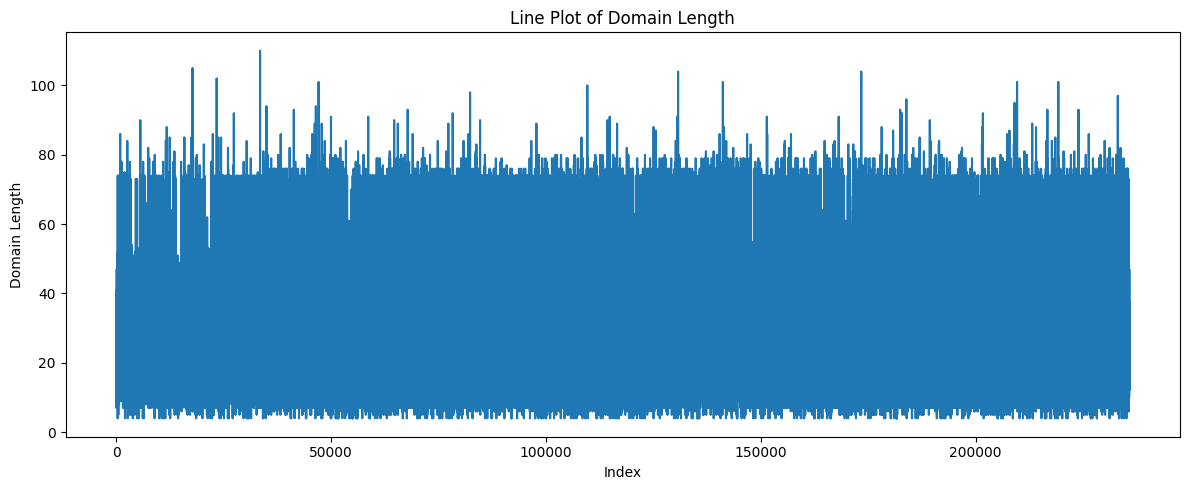

In [ ]:
# Line plot for single feature (Domain Length)
plt.figure(figsize=(12, 5))
sns.lineplot(data=df['DomainLength'])
plt.title("Line Plot of Domain Length")
plt.xlabel("Index")
plt.ylabel("Domain Length")
plt.tight_layout()
plt.show()

# Vertical Bar Plot

In [ ]:
# Divide dataset by class (phishing vs. legitimate)
grouped_df = df.groupby('label')

# Calculate difference and return top N
def top_n_features(df, n=5):
  diff = df.std() - df.mean()
  return diff.sort_values(ascending=False)[:n]

/tmp/ipykernel_479/1974018657.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_df = df.groupby('label')


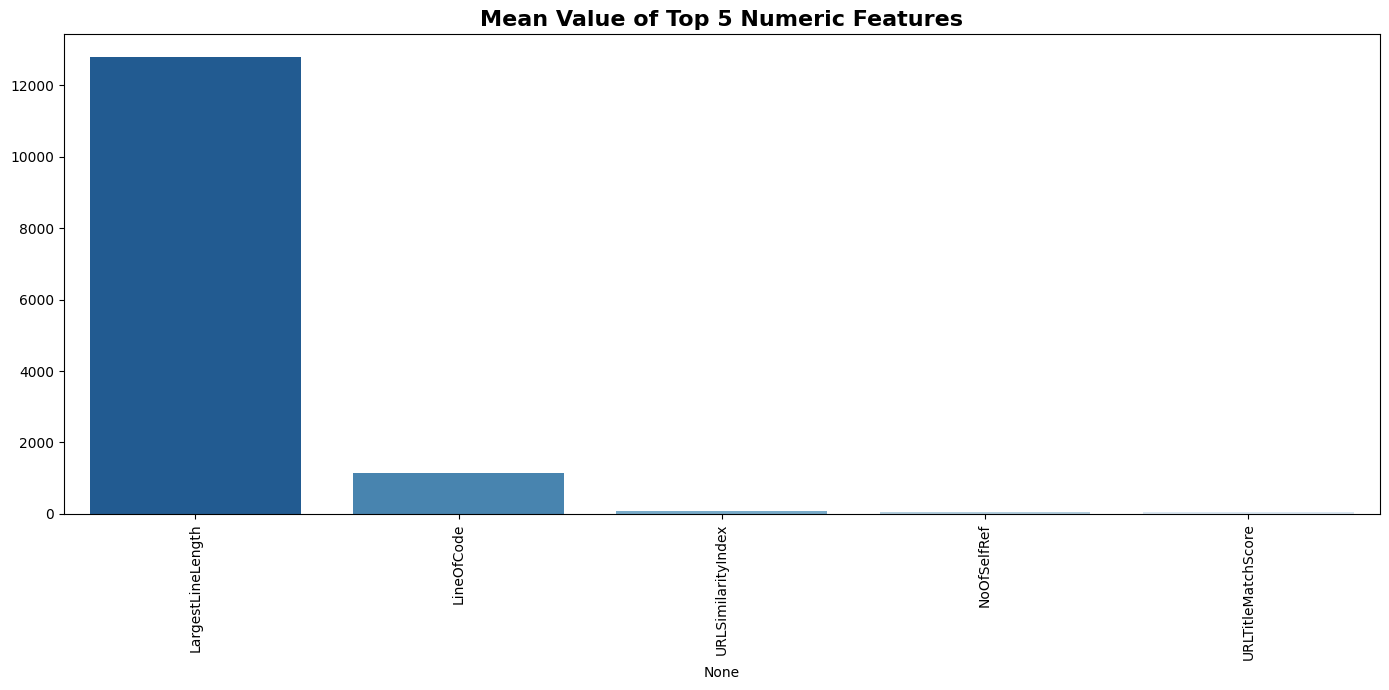

In [ ]:
# Calculate the mean
feature_means = numeric_df.drop(columns=['label'], errors='ignore').mean().sort_values(ascending=False)

# Select top N values
top_n_means = feature_means.head(5)

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(x=top_n_means.index, y=top_n_means.values, hue=top_n_means.index, palette="Blues_r", legend=False)
plt.title("Mean Value of Top 5 Numeric Features", fontsize=16, weight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

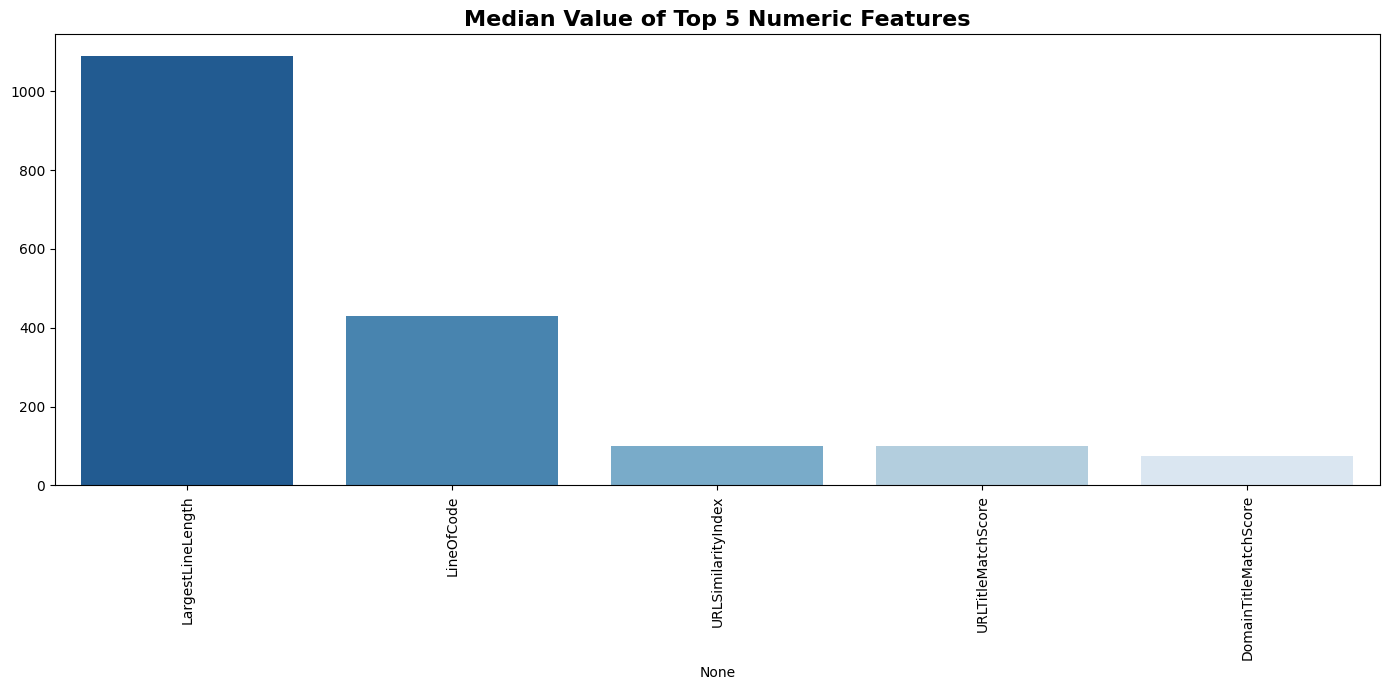

In [ ]:
# Calculate the median
feature_medians = numeric_df.drop(columns=['label'], errors='ignore').median().sort_values(ascending=False)

# Select top N values
top_n_medians = feature_medians.head(5)

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(x=top_n_medians.index, y=top_n_medians.values, hue=top_n_medians.index, palette="Blues_r", legend=False)
plt.title("Median Value of Top 5 Numeric Features", fontsize=16, weight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

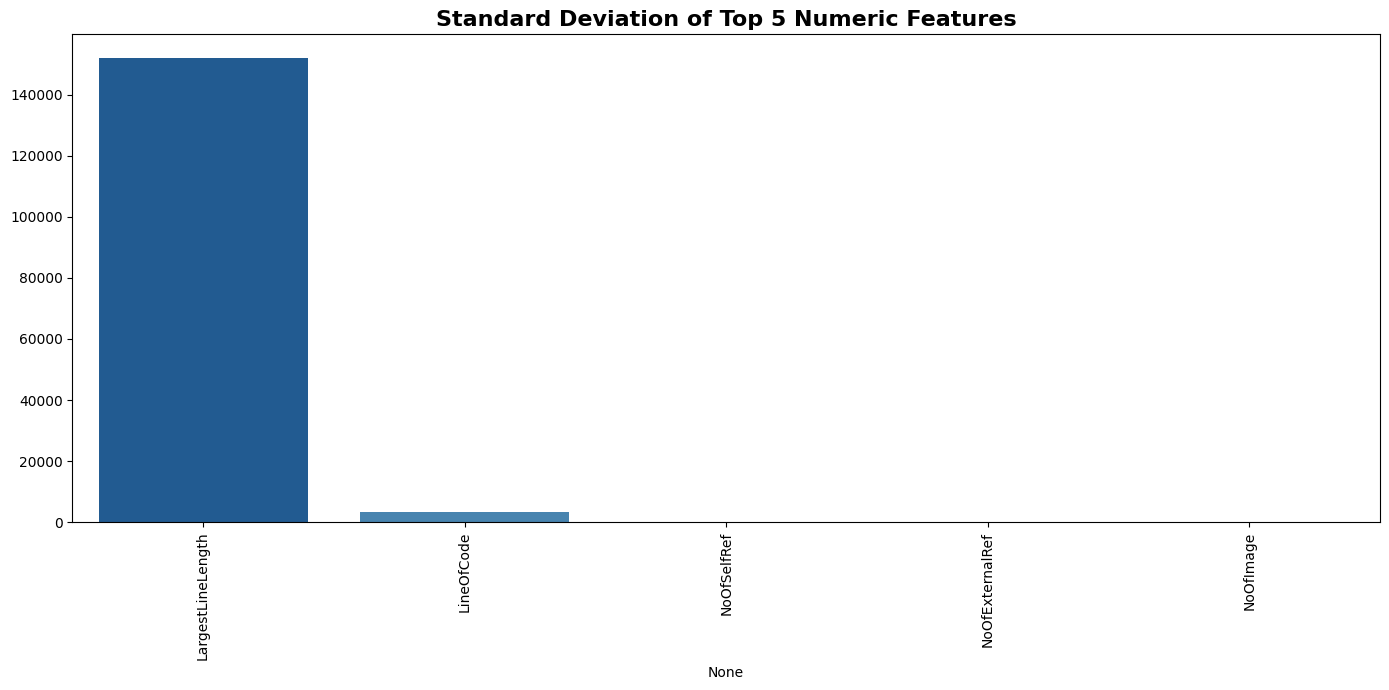

In [ ]:
# Calculate the standard deviation
feature_stds = numeric_df.drop(columns=['label'], errors='ignore').std().sort_values(ascending=False)

# Select top N values
top_n_stds = feature_stds.head(5)

# Plot
plt.figure(figsize=(14, 7))
sns.barplot(x=top_n_stds.index, y=top_n_stds.values, hue=top_n_stds.index, palette="Blues_r", legend=False)
plt.title("Standard Deviation of Top 5 Numeric Features", fontsize=16, weight="bold")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Horizontal Bar Plot

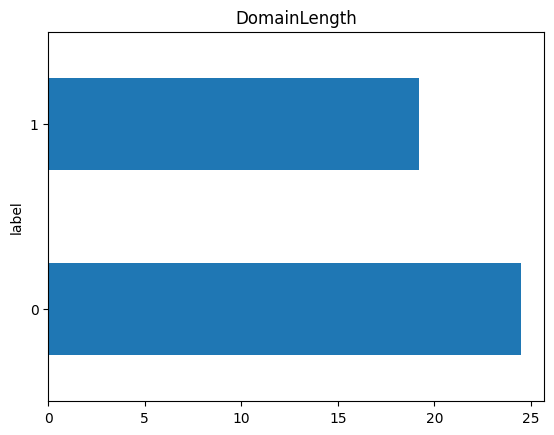

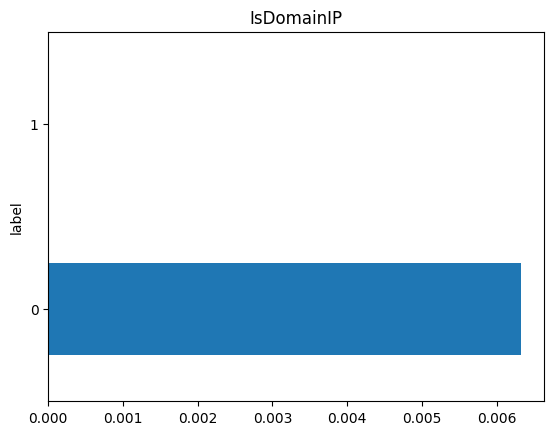

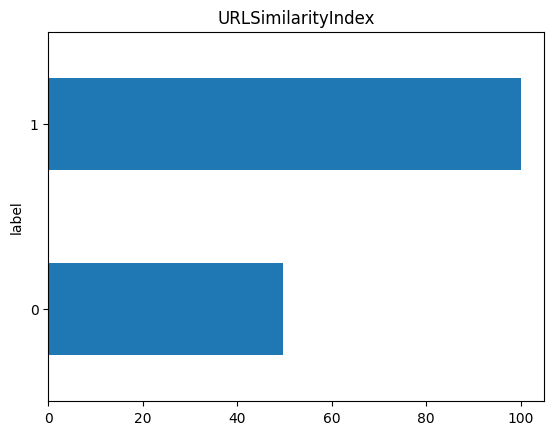

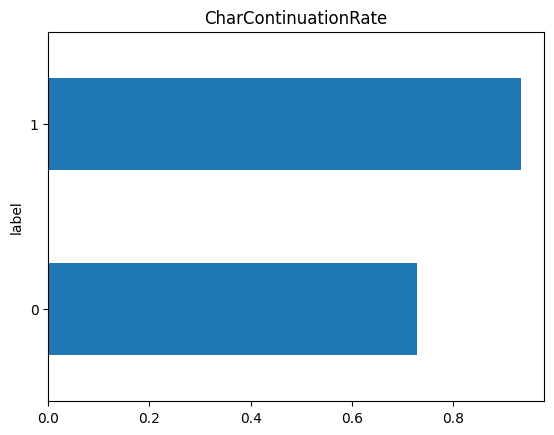

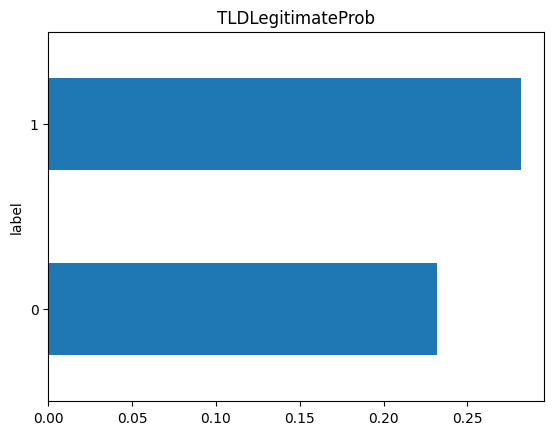

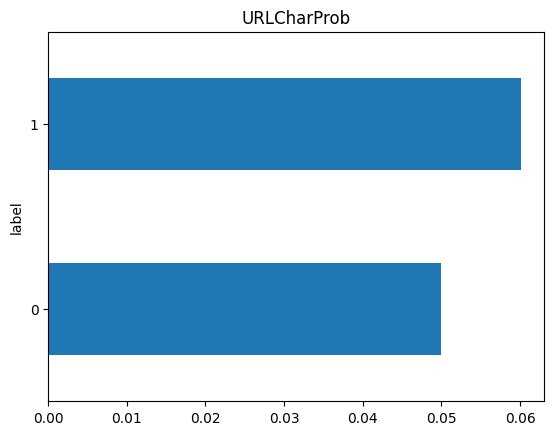

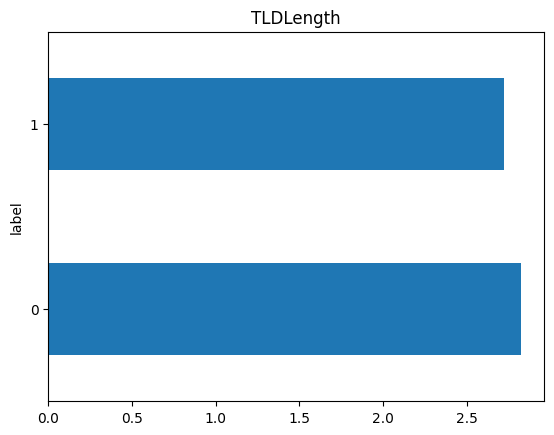

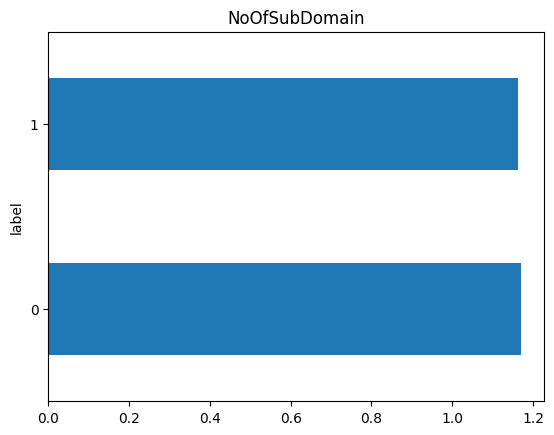

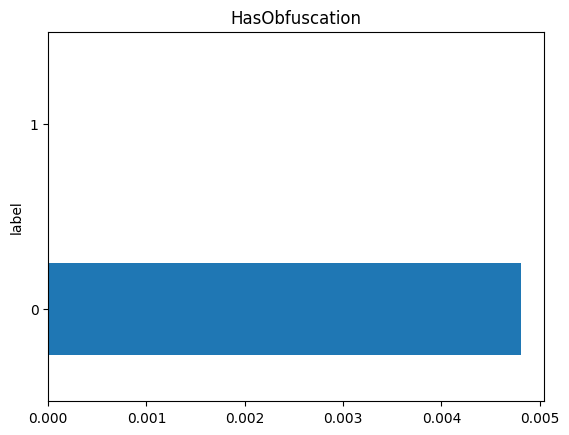

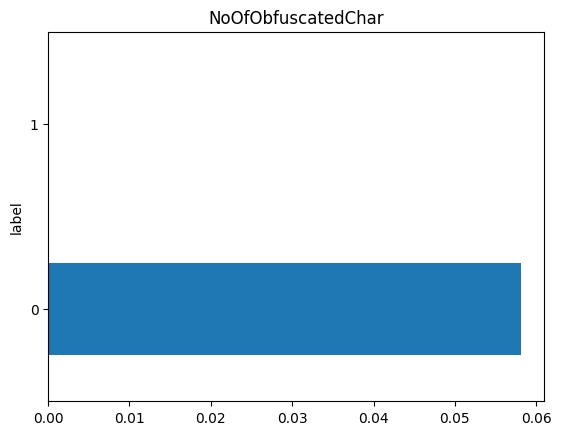

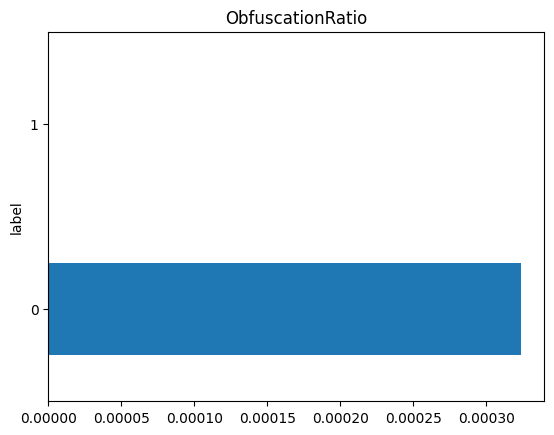

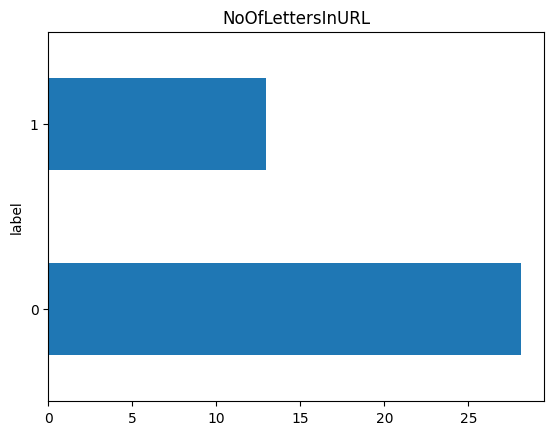

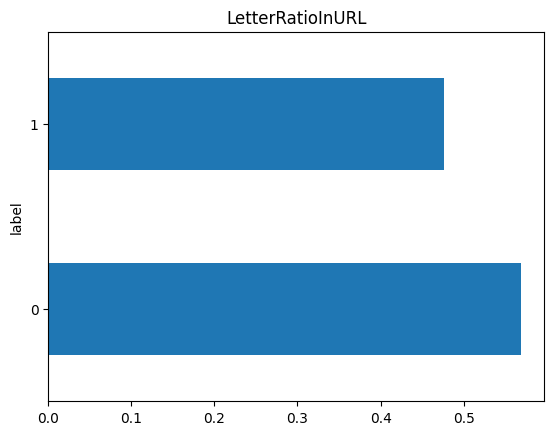

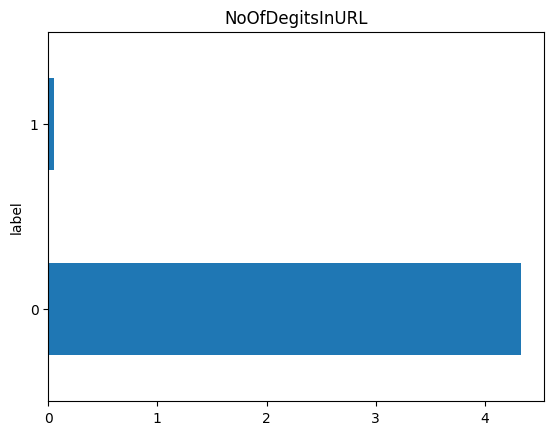

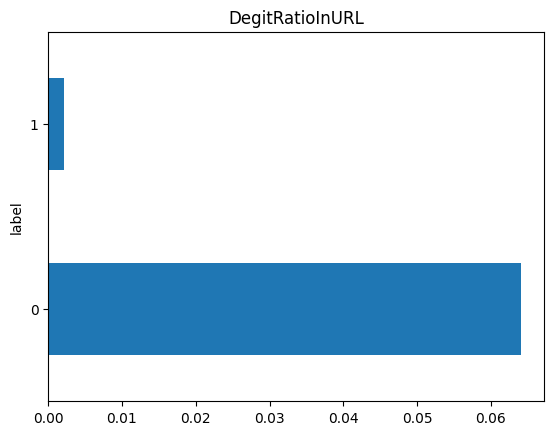

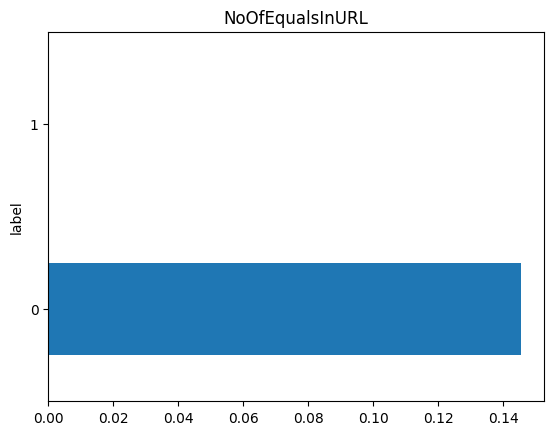

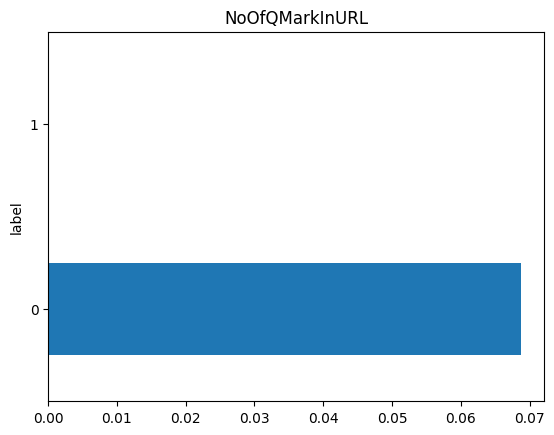

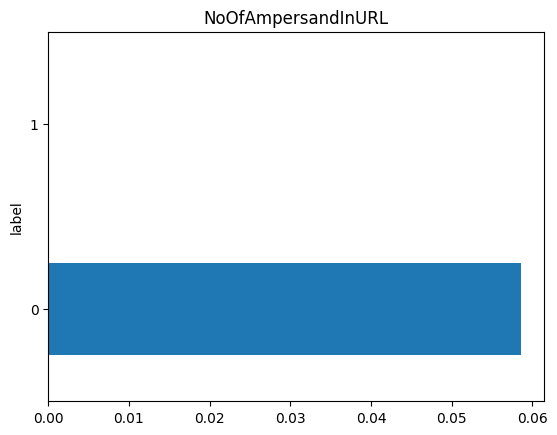

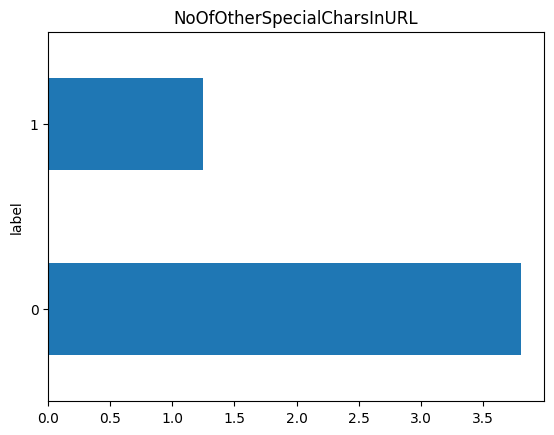

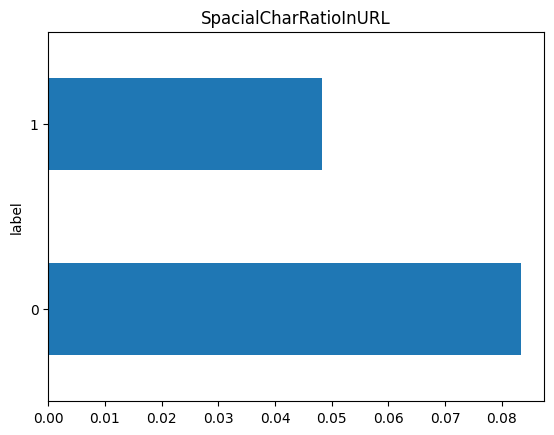

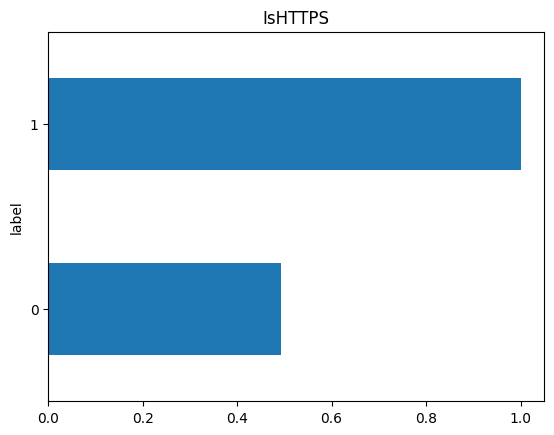

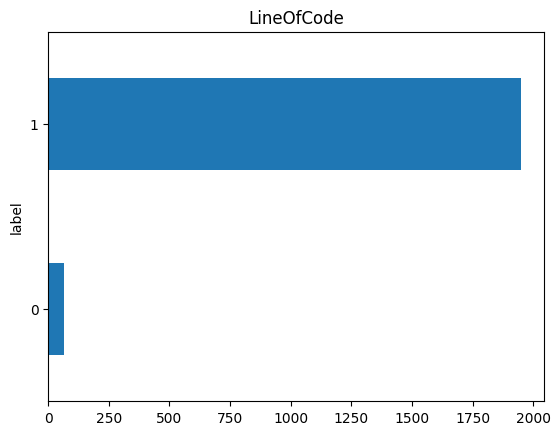

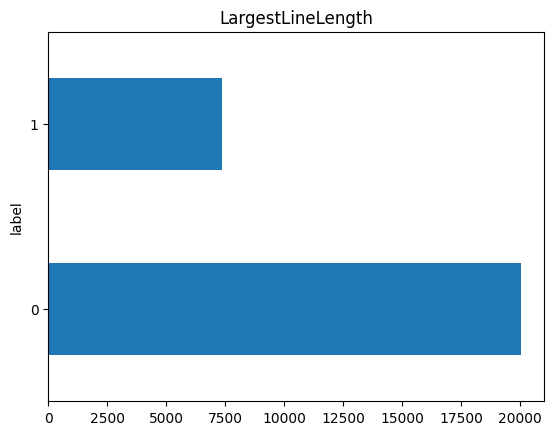

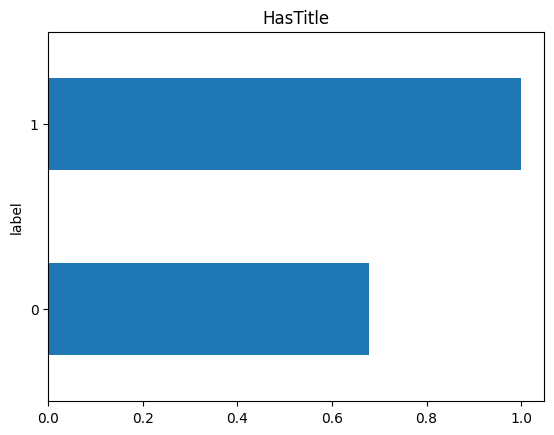

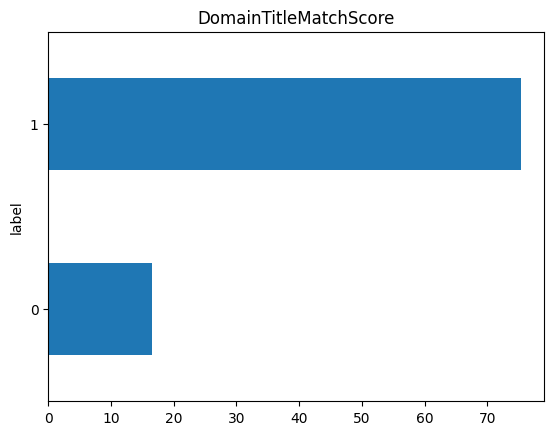

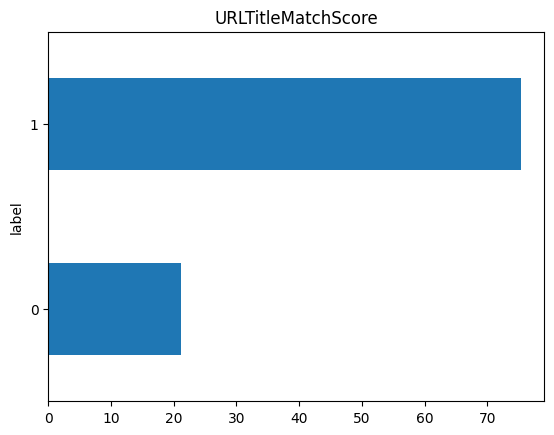

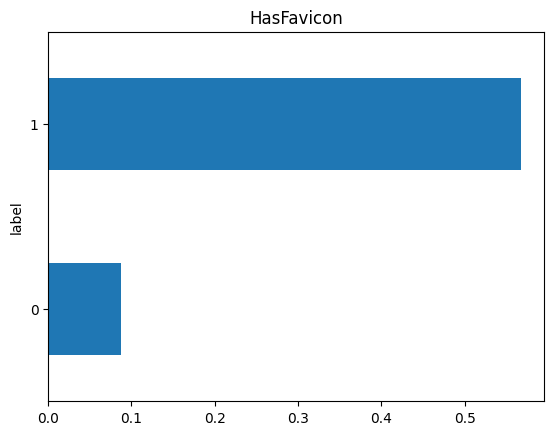

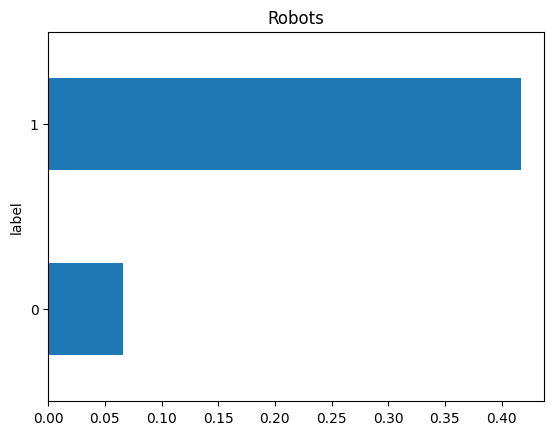

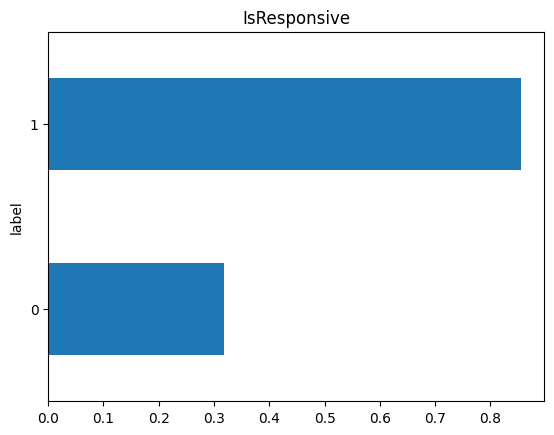

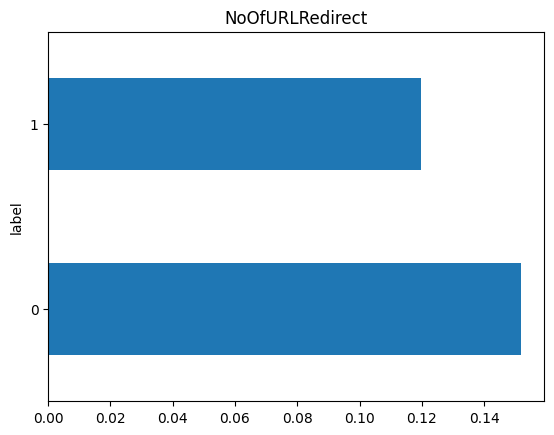

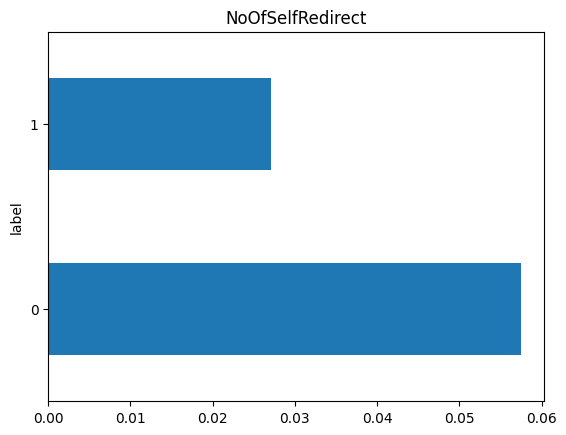

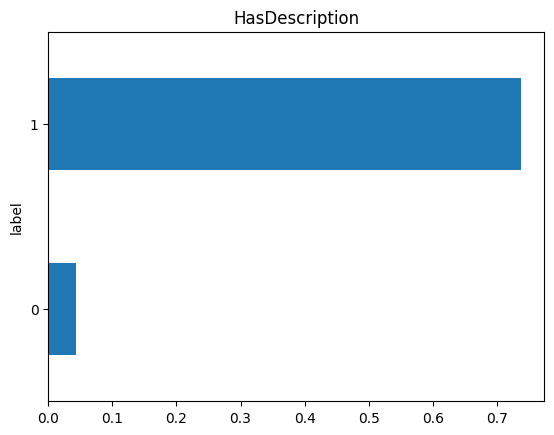

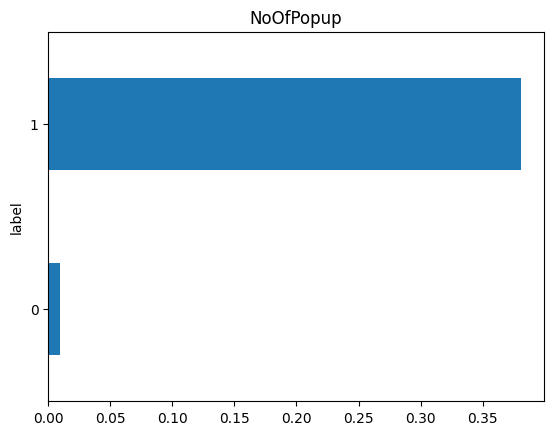

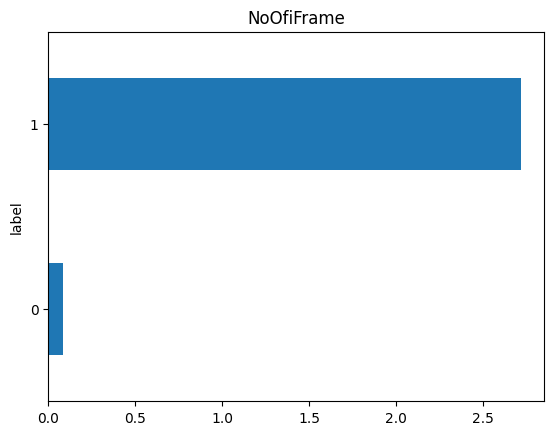

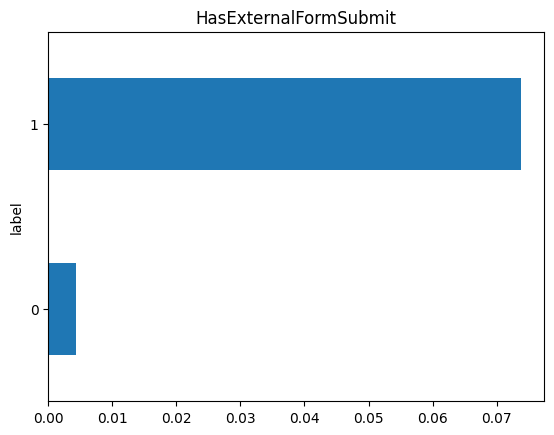

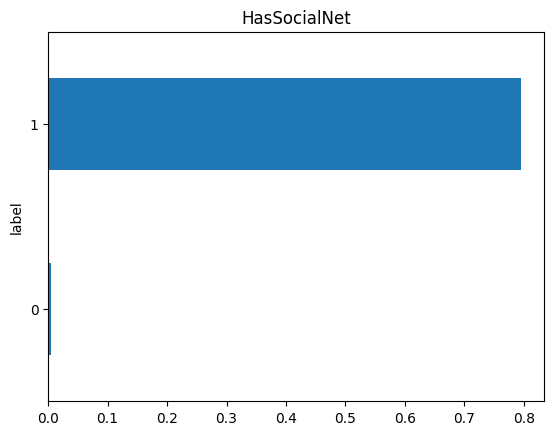

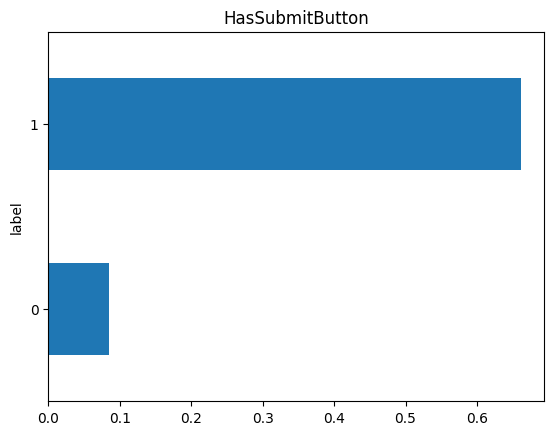

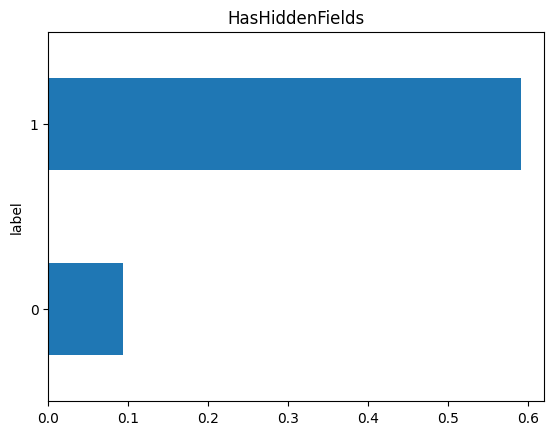

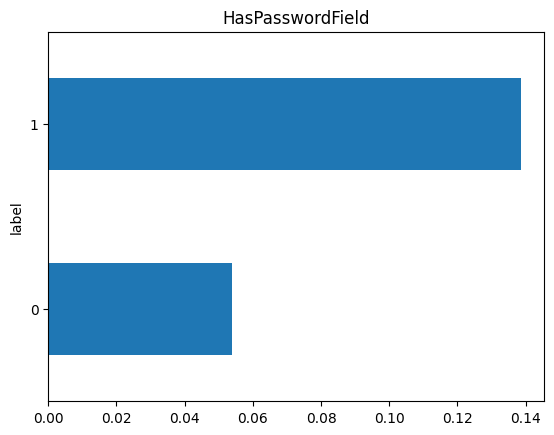

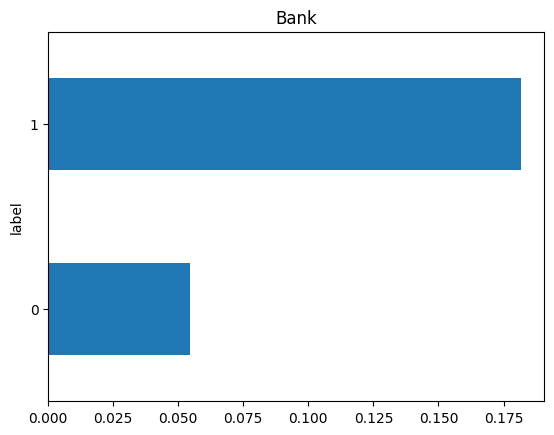

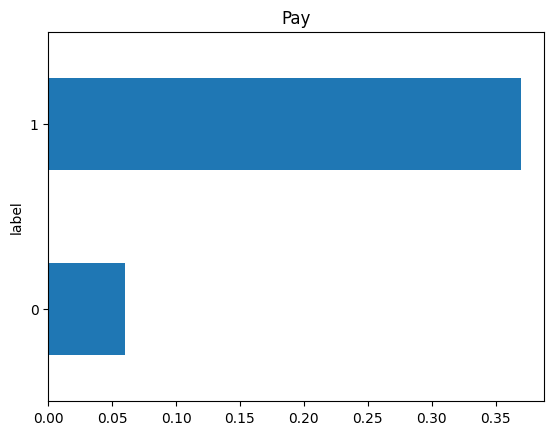

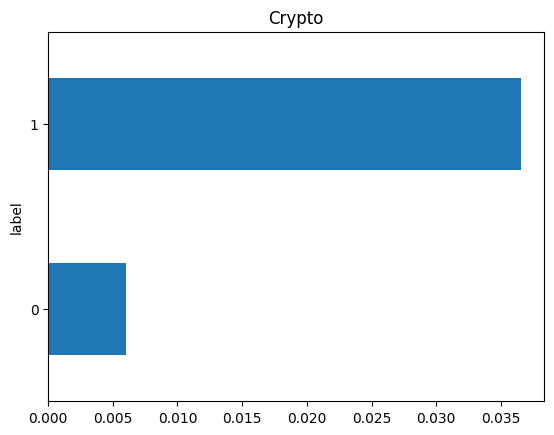

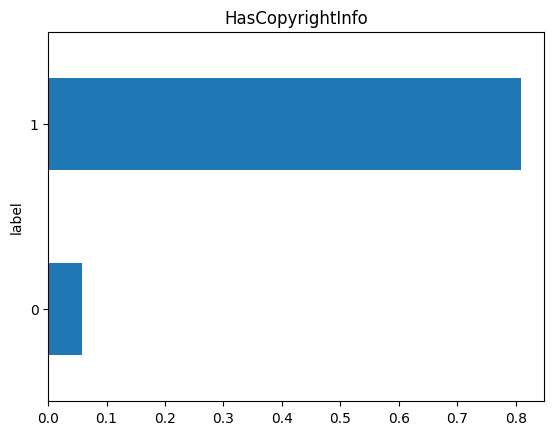

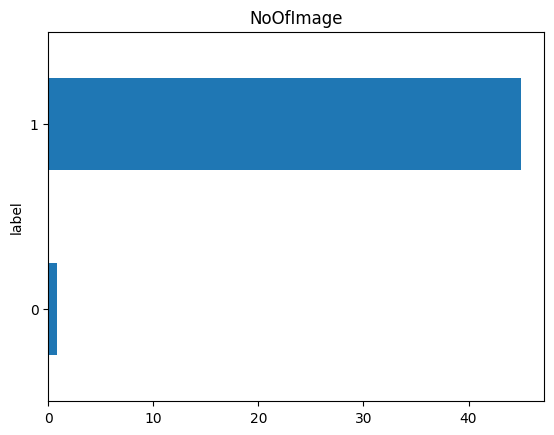

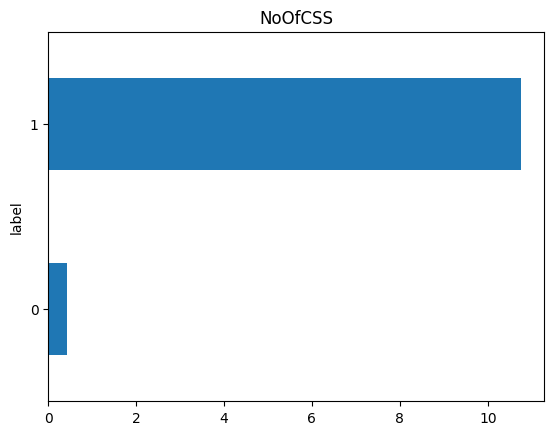

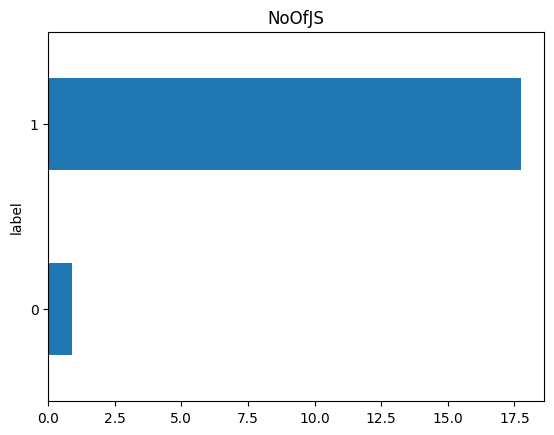

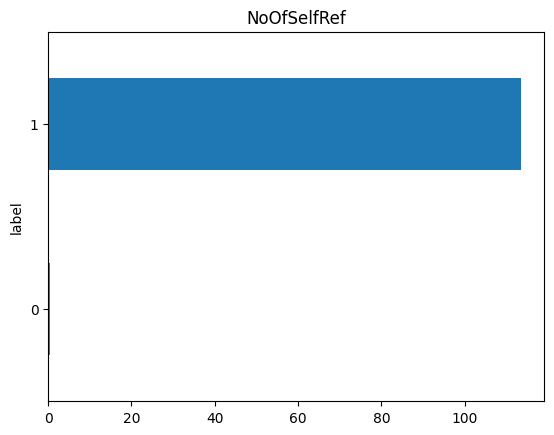

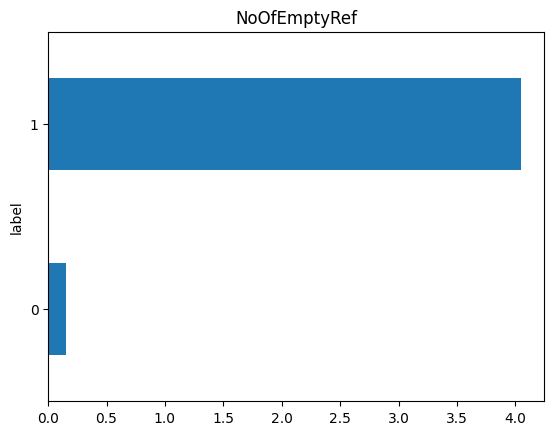

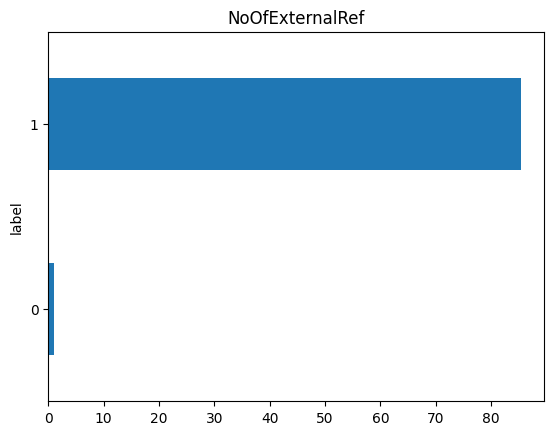

In [ ]:
df1 = numeric_df.drop(columns=['URLLength'])
df1['label'] = y['label']

for col in df1.columns:
    if col != 'label':
        plt.figure()
        df1.groupby('label')[col].mean().plot(kind='barh')
        plt.title(col)
        plt.show()


# Histograms



array([[<Axes: title={'center': 'URLLength'}>,
        <Axes: title={'center': 'DomainLength'}>,
        <Axes: title={'center': 'URLSimilarityIndex'}>,
        <Axes: title={'center': 'CharContinuationRate'}>,
        <Axes: title={'center': 'TLDLegitimateProb'}>,
        <Axes: title={'center': 'URLCharProb'}>],
       [<Axes: title={'center': 'TLDLength'}>,
        <Axes: title={'center': 'NoOfSubDomain'}>,
        <Axes: title={'center': 'NoOfObfuscatedChar'}>,
        <Axes: title={'center': 'ObfuscationRatio'}>,
        <Axes: title={'center': 'NoOfLettersInURL'}>,
        <Axes: title={'center': 'LetterRatioInURL'}>],
       [<Axes: title={'center': 'NoOfDegitsInURL'}>,
        <Axes: title={'center': 'DegitRatioInURL'}>,
        <Axes: title={'center': 'NoOfEqualsInURL'}>,
        <Axes: title={'center': 'NoOfQMarkInURL'}>,
        <Axes: title={'center': 'NoOfAmpersandInURL'}>,
        <Axes: title={'center': 'NoOfOtherSpecialCharsInURL'}>],
       [<Axes: title={'center': 'Sp

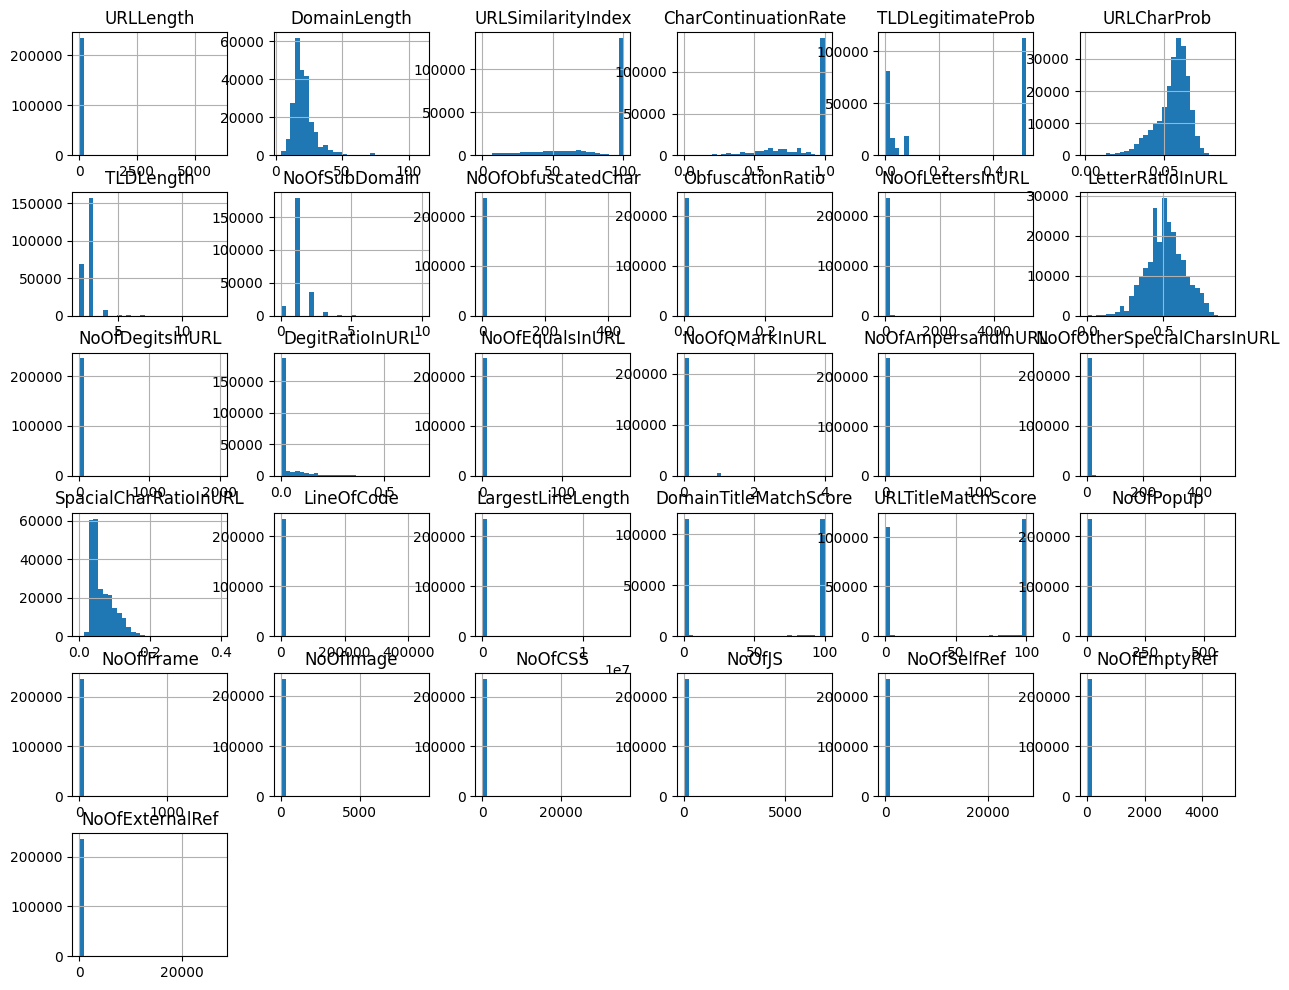

In [ ]:
df.drop(columns='label').hist(figsize=(15,12), bins=30)

# Pie Charts

<Axes: ylabel='count'>

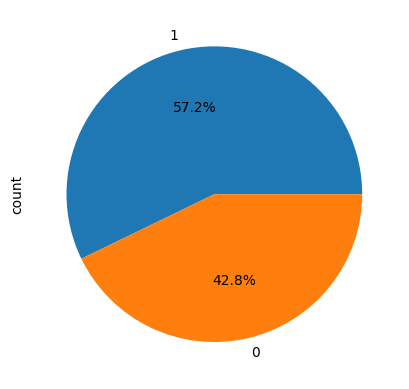

In [ ]:
df['label'].value_counts().plot(kind='pie', autopct='%1.1f%%')

# Box-and-Whisker Plot

URLLength: Q1 23.00, Q3 34.00, IQR 11.00, Lower Bound 6.50, Upper Bound 50.50, Num Outliers: 22493


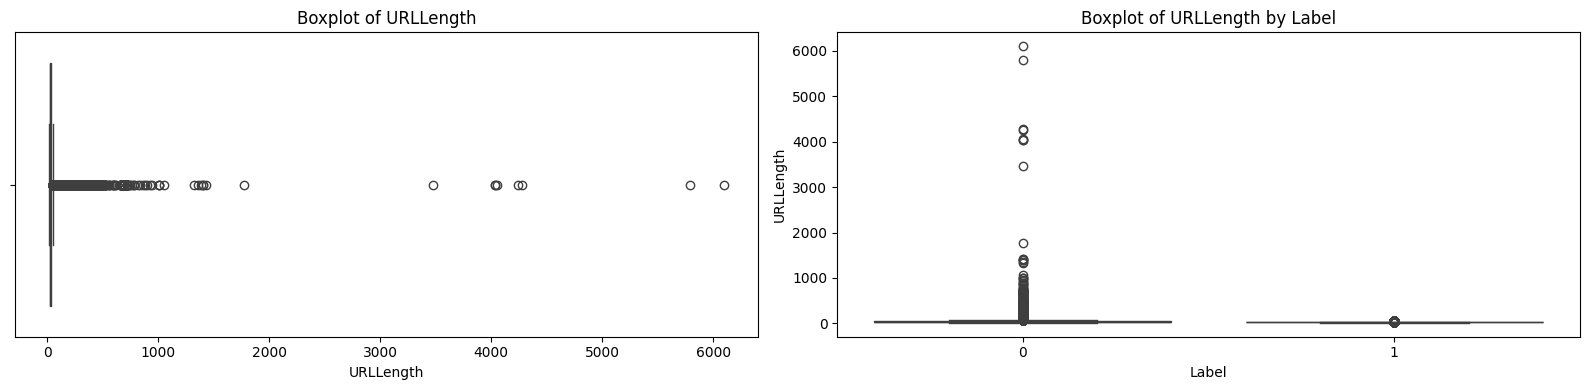

DomainLength: Q1 16.00, Q3 24.00, IQR 8.00, Lower Bound 4.00, Upper Bound 36.00, Num Outliers: 13474


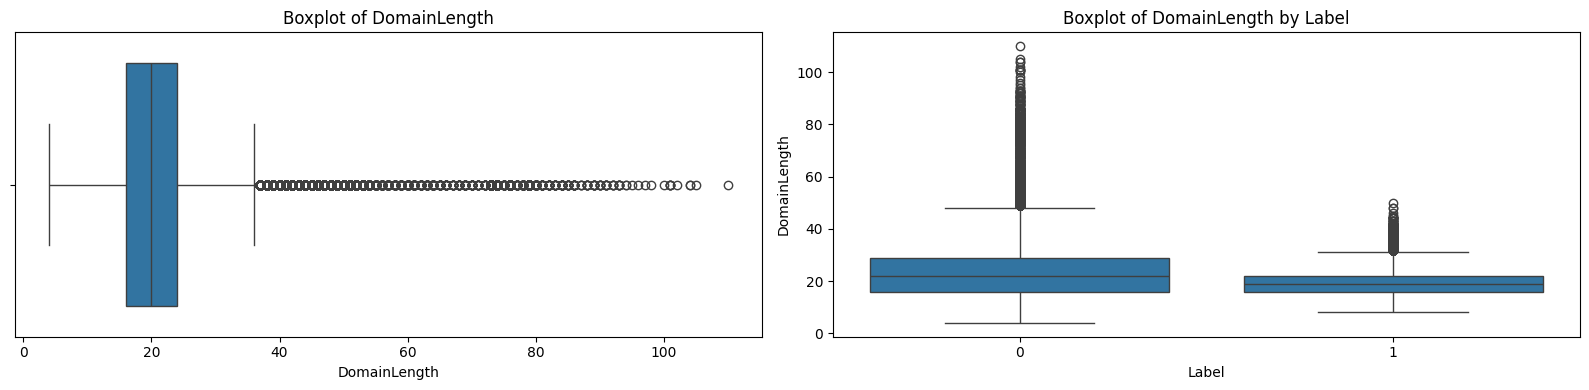

IsDomainIP: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 638


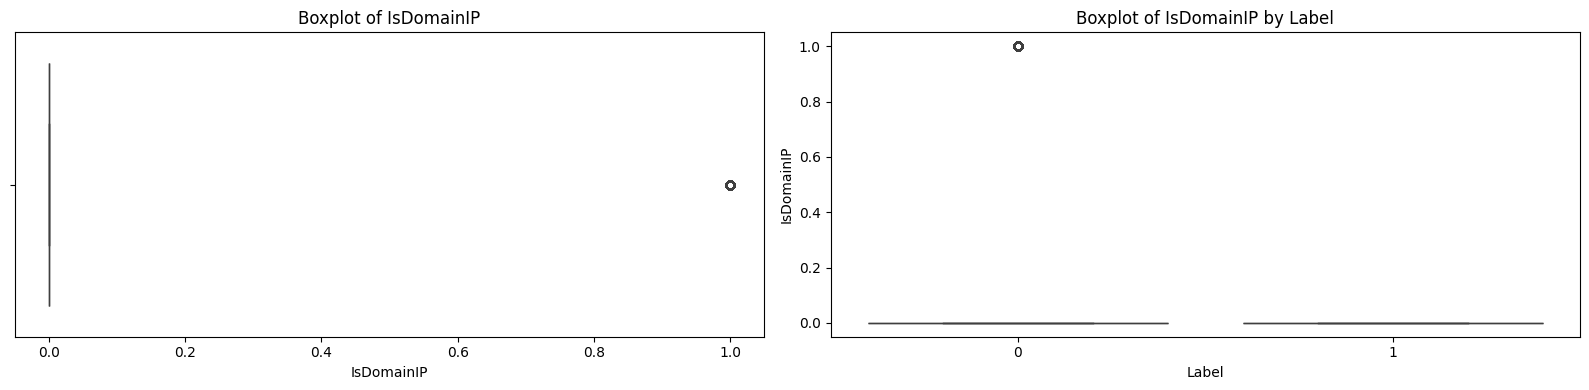

URLSimilarityIndex: Q1 57.02, Q3 100.00, IQR 42.98, Lower Bound -7.44, Upper Bound 164.46, Num Outliers: 0


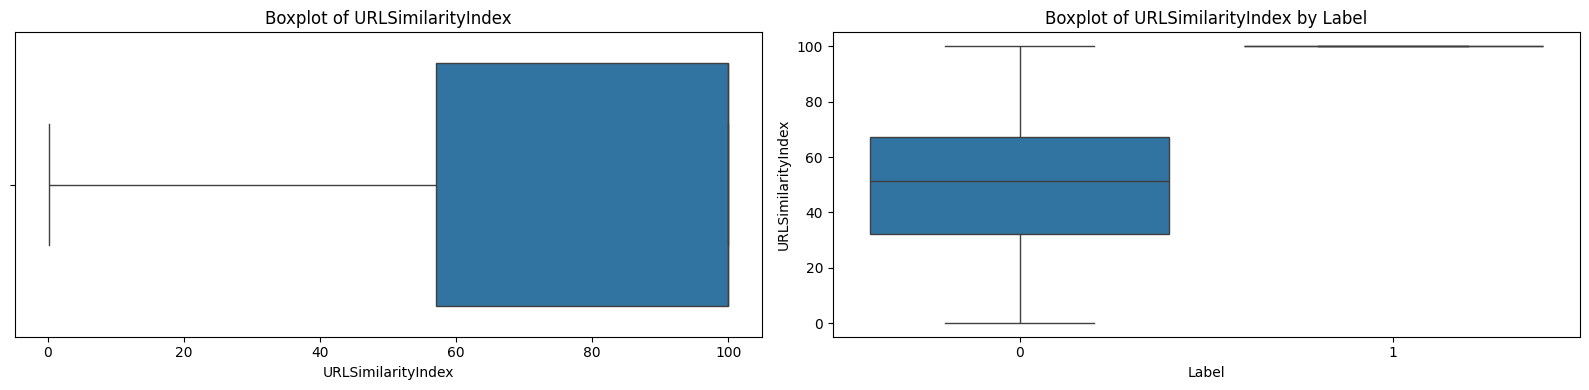

CharContinuationRate: Q1 0.68, Q3 1.00, IQR 0.32, Lower Bound 0.20, Upper Bound 1.48, Num Outliers: 679


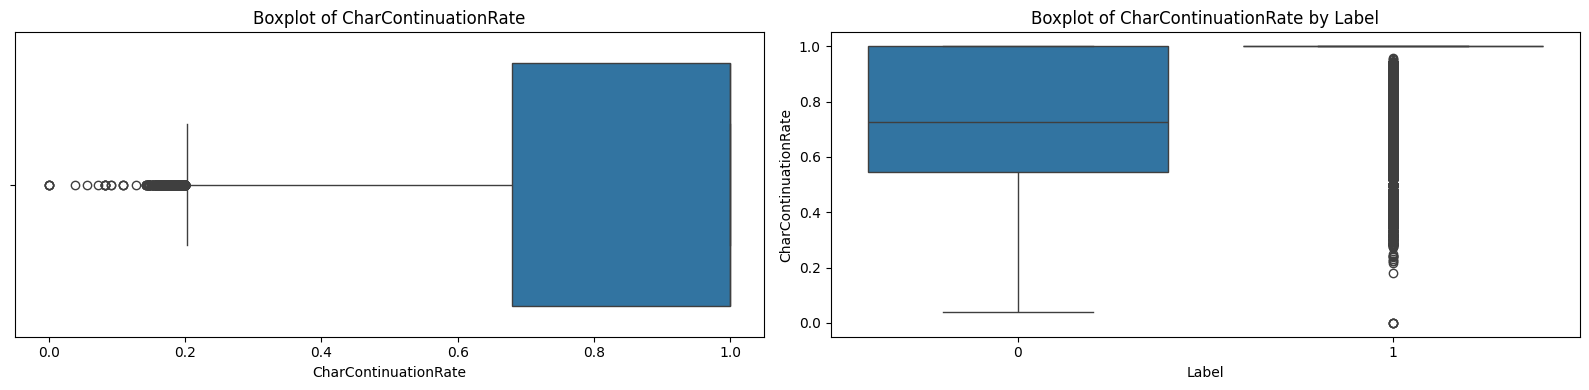

TLDLegitimateProb: Q1 0.01, Q3 0.52, IQR 0.52, Lower Bound -0.77, Upper Bound 1.30, Num Outliers: 0


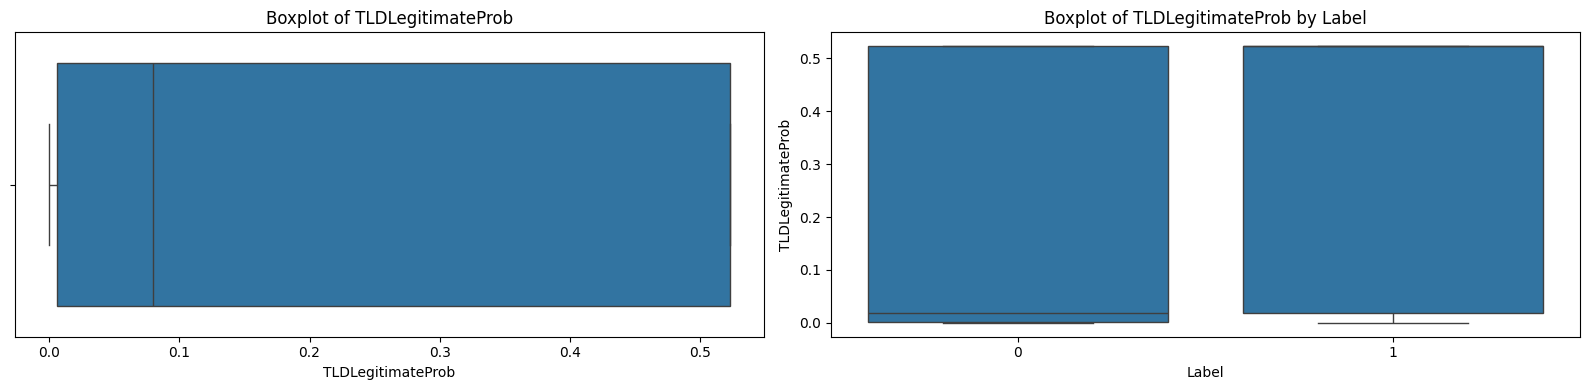

URLCharProb: Q1 0.05, Q3 0.06, IQR 0.01, Lower Bound 0.03, Upper Bound 0.08, Num Outliers: 8569


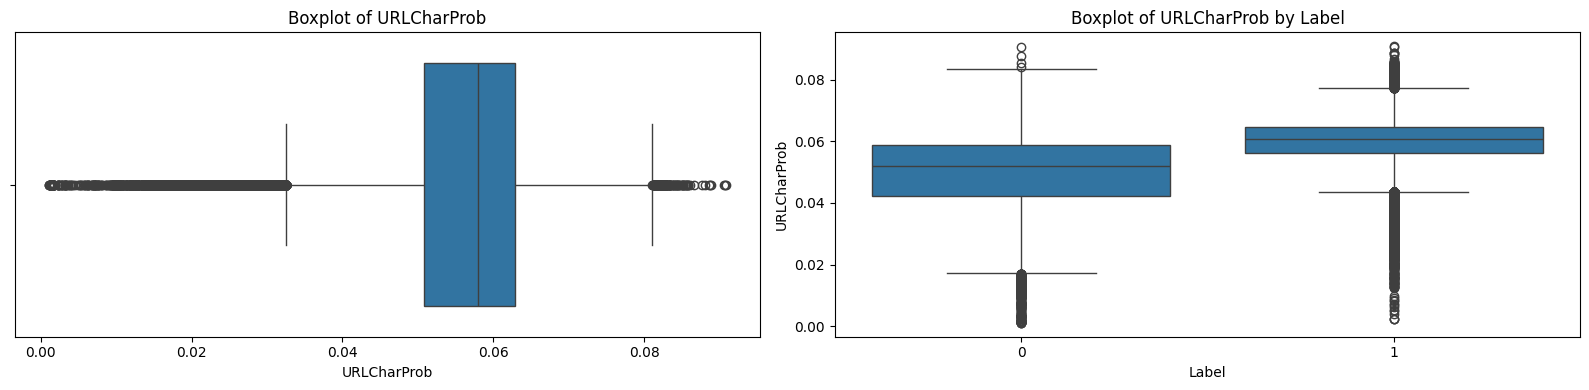

TLDLength: Q1 2.00, Q3 3.00, IQR 1.00, Lower Bound 0.50, Upper Bound 4.50, Num Outliers: 2134


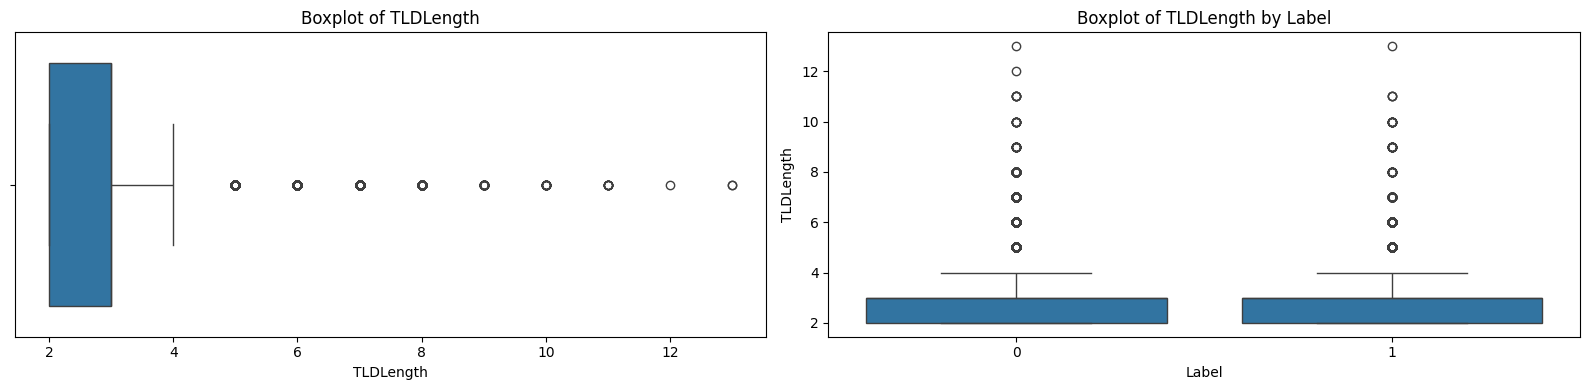

NoOfSubDomain: Q1 1.00, Q3 1.00, IQR 0.00, Lower Bound 1.00, Upper Bound 1.00, Num Outliers: 57389


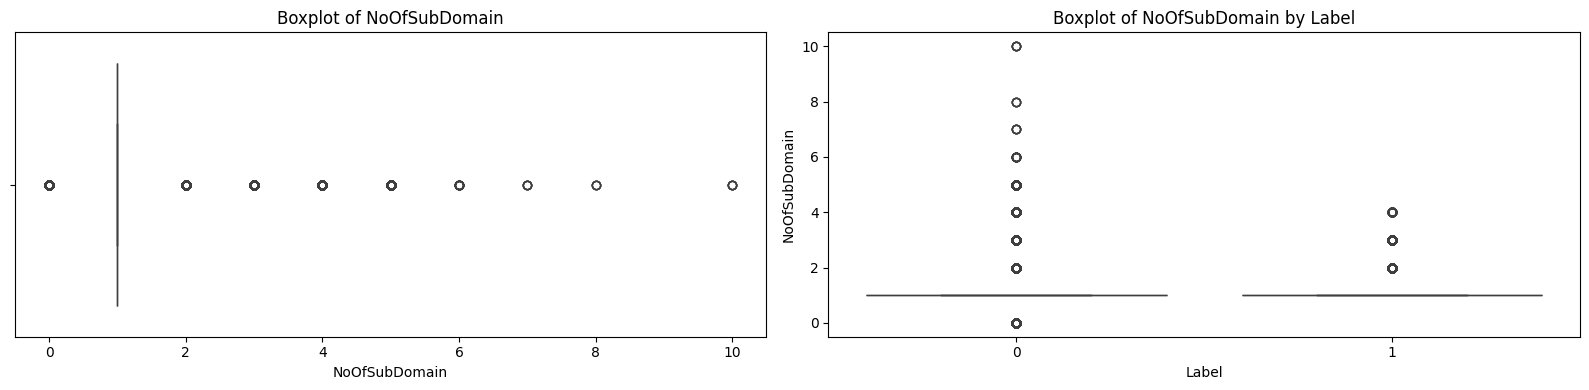

HasObfuscation: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 485


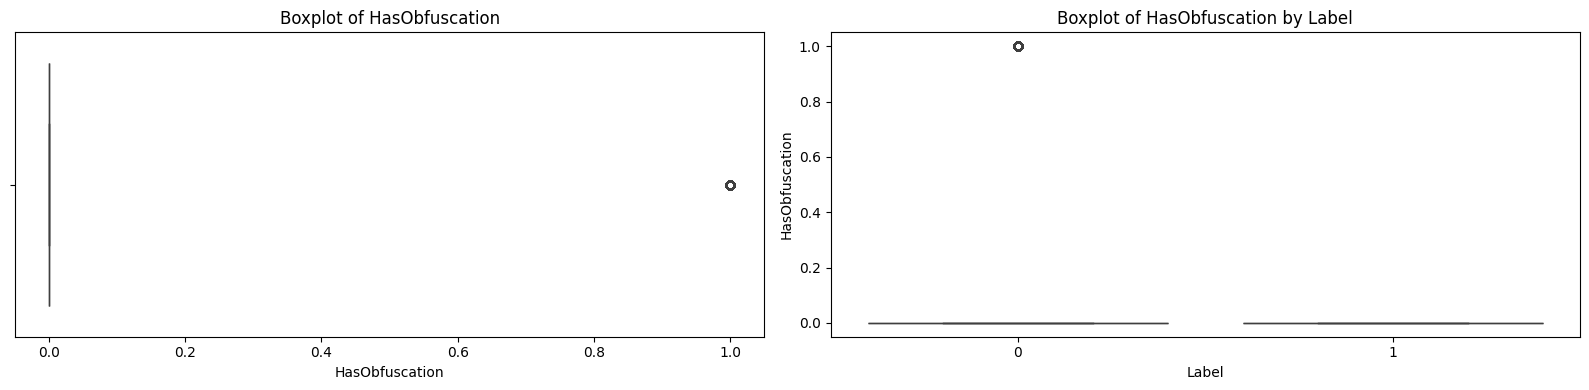

NoOfObfuscatedChar: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 485


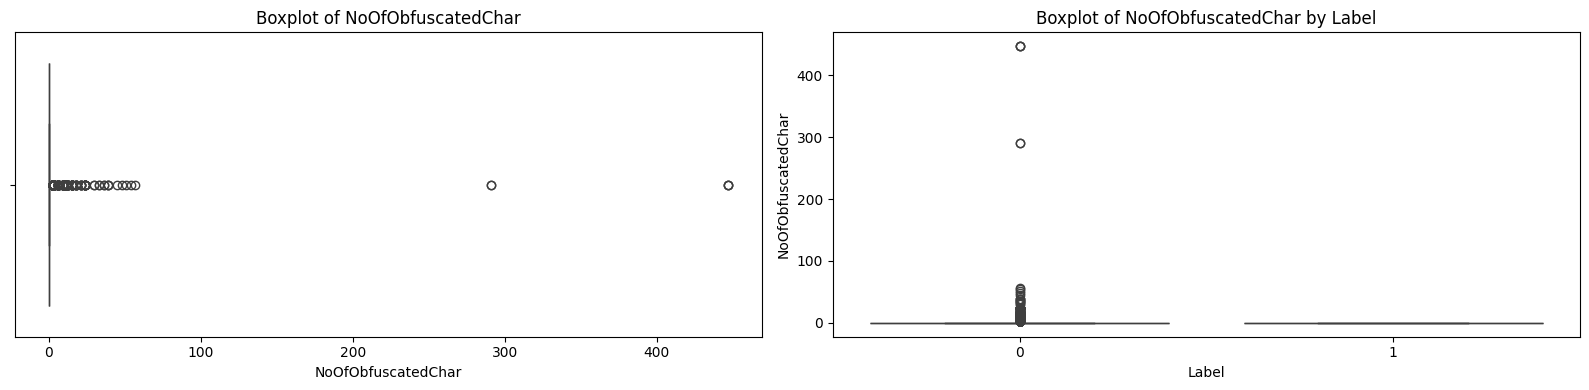

ObfuscationRatio: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 485


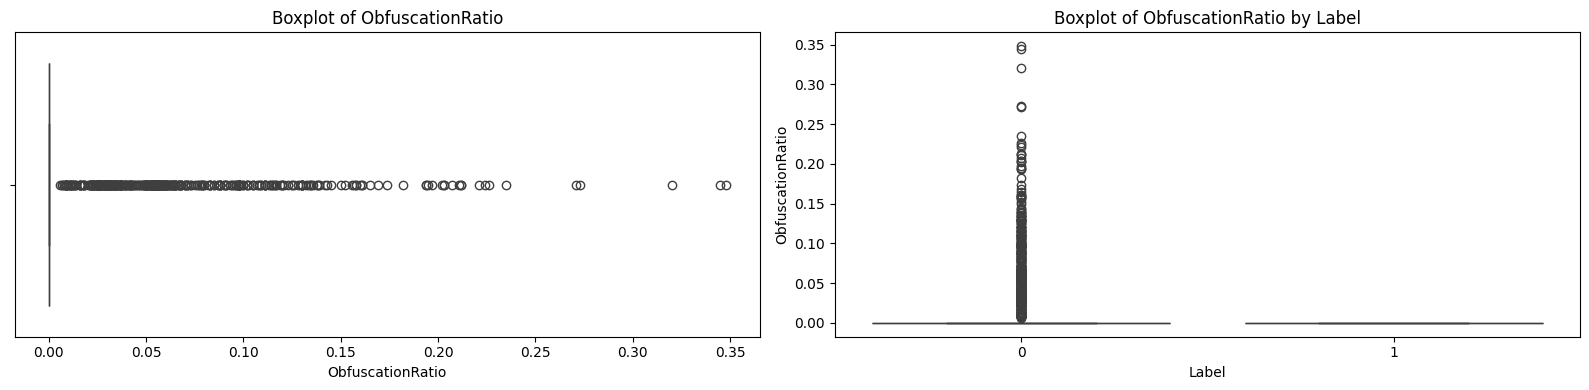

NoOfLettersInURL: Q1 10.00, Q3 20.00, IQR 10.00, Lower Bound -5.00, Upper Bound 35.00, Num Outliers: 19662


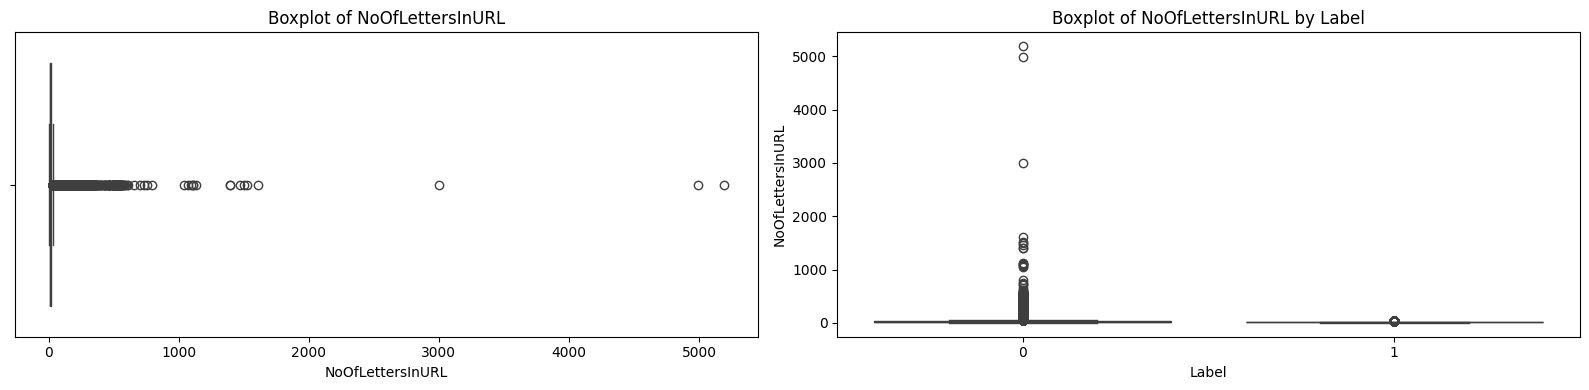

LetterRatioInURL: Q1 0.43, Q3 0.59, IQR 0.16, Lower Bound 0.20, Upper Bound 0.83, Num Outliers: 1417


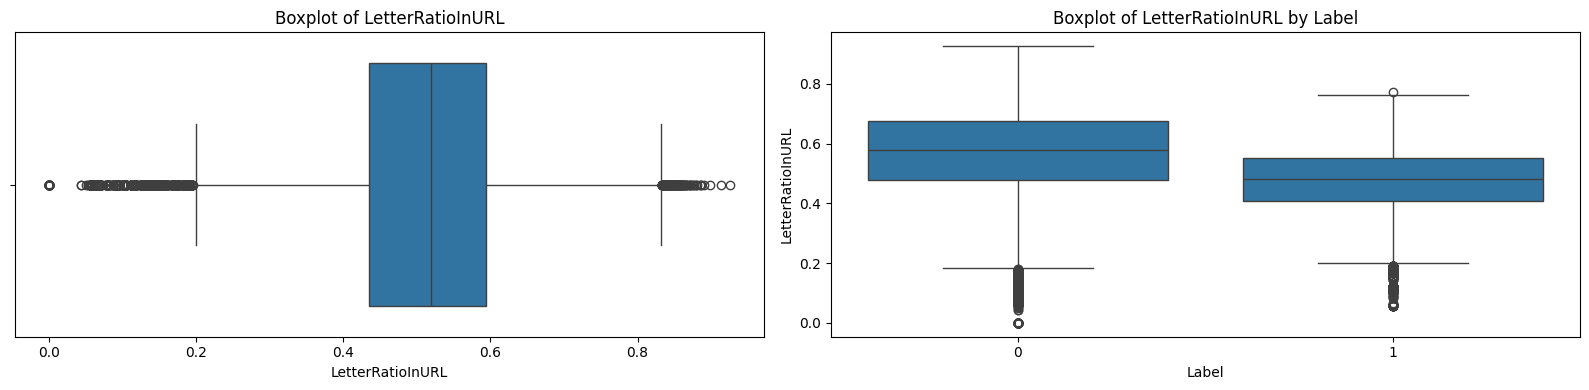

NoOfDegitsInURL: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 51461


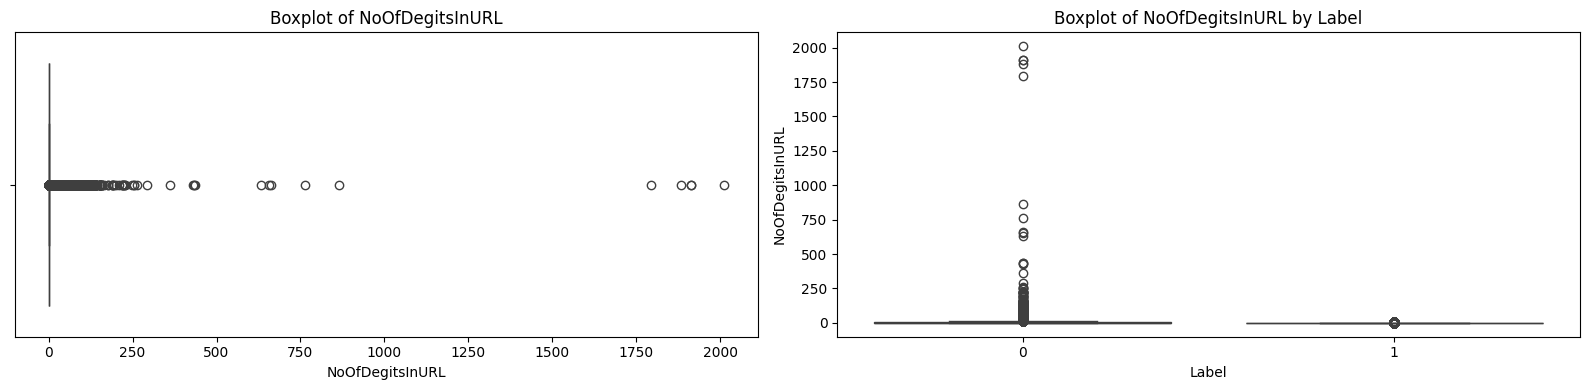

DegitRatioInURL: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 51461


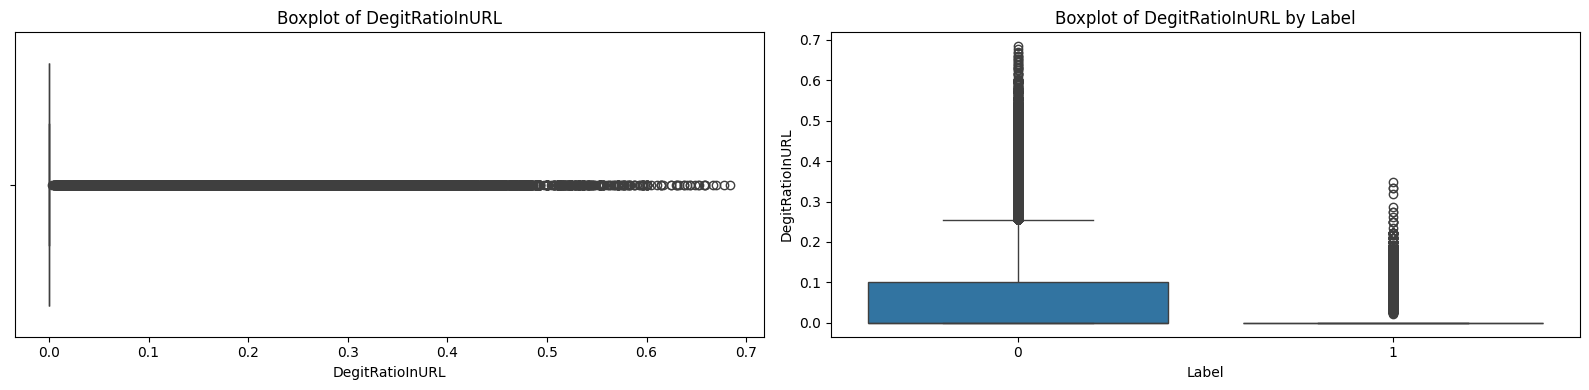

NoOfEqualsInURL: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 5401


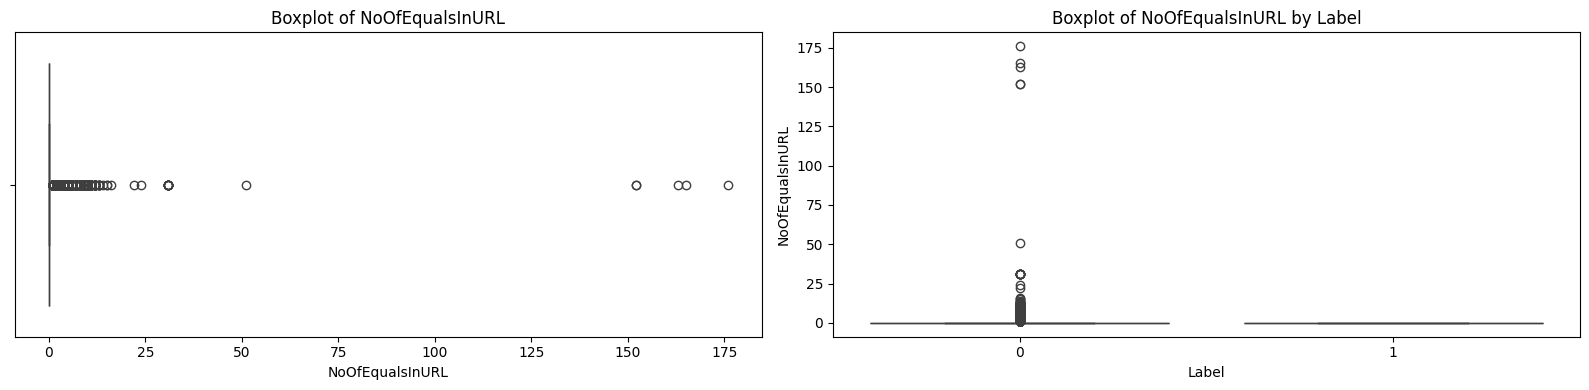

NoOfQMarkInURL: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 6130


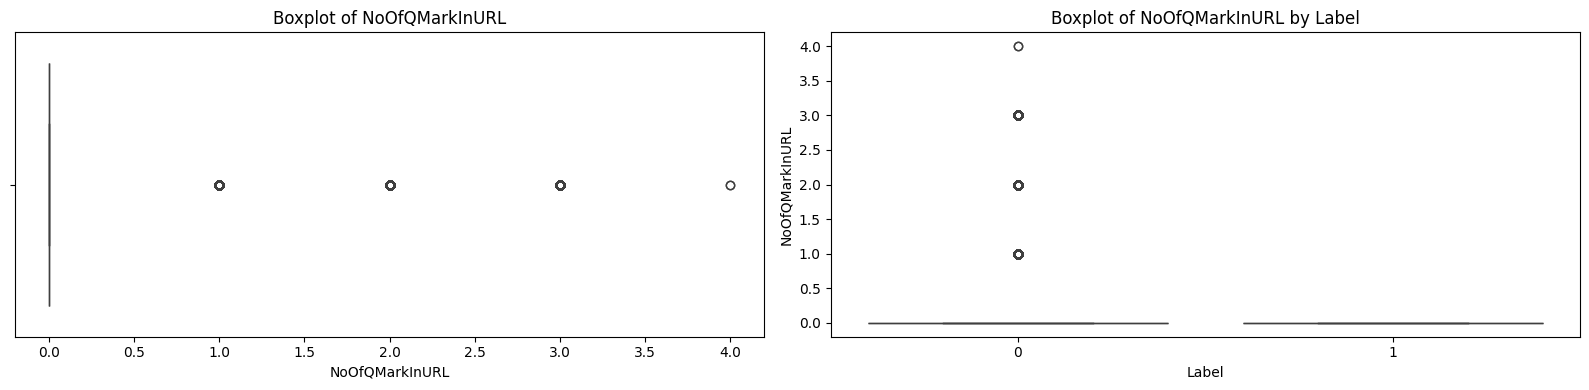

NoOfAmpersandInURL: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 887


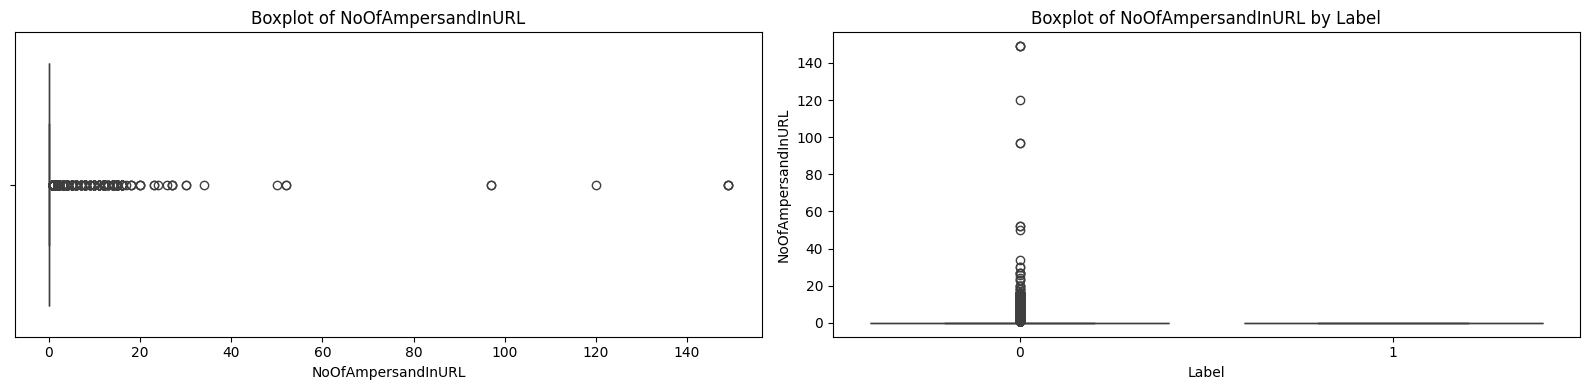

NoOfOtherSpecialCharsInURL: Q1 1.00, Q3 3.00, IQR 2.00, Lower Bound -2.00, Upper Bound 6.00, Num Outliers: 12380


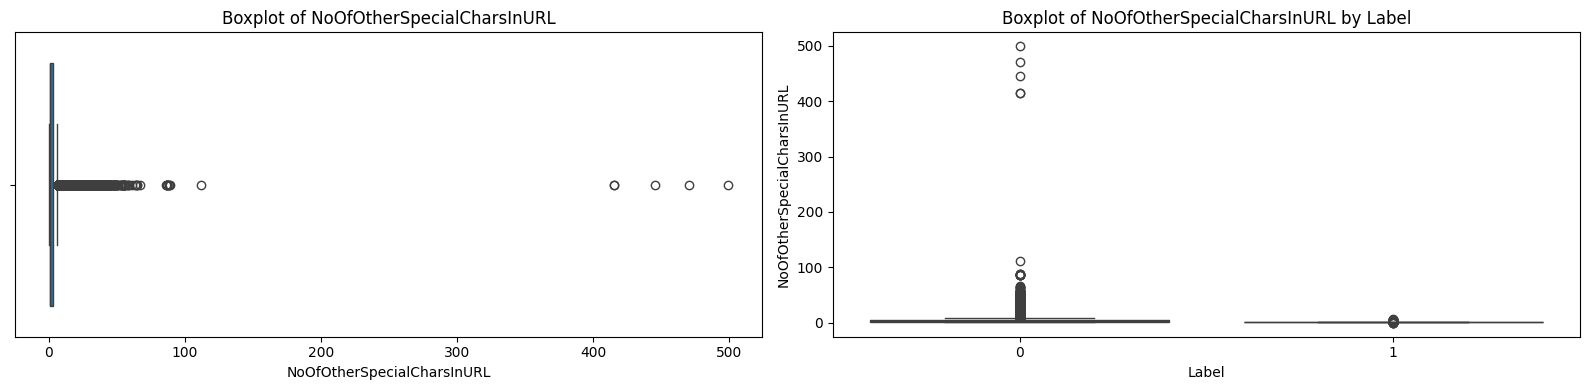

SpacialCharRatioInURL: Q1 0.04, Q3 0.08, IQR 0.05, Lower Bound -0.03, Upper Bound 0.15, Num Outliers: 3344


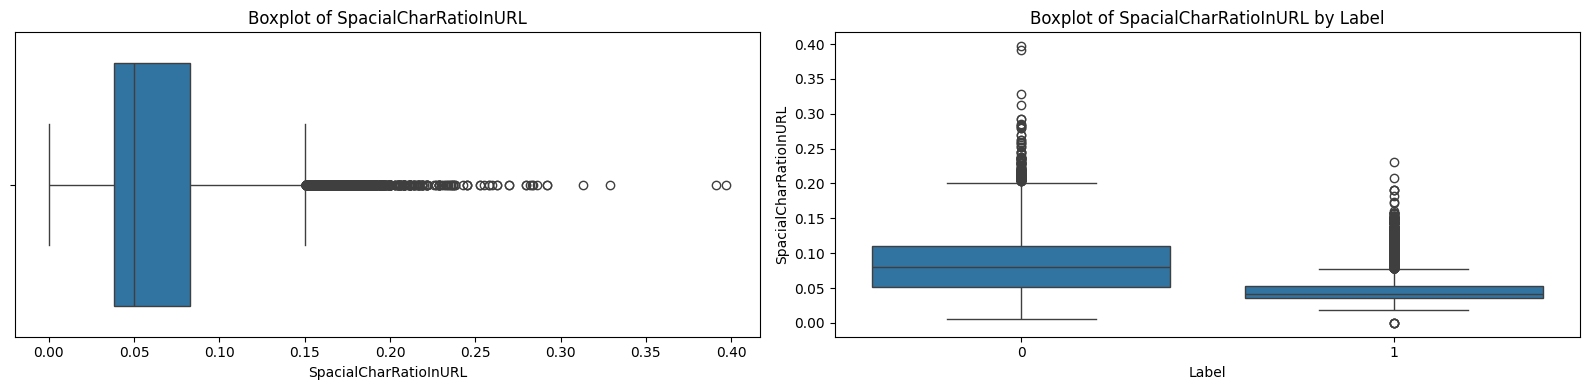

IsHTTPS: Q1 1.00, Q3 1.00, IQR 0.00, Lower Bound 1.00, Upper Bound 1.00, Num Outliers: 51256


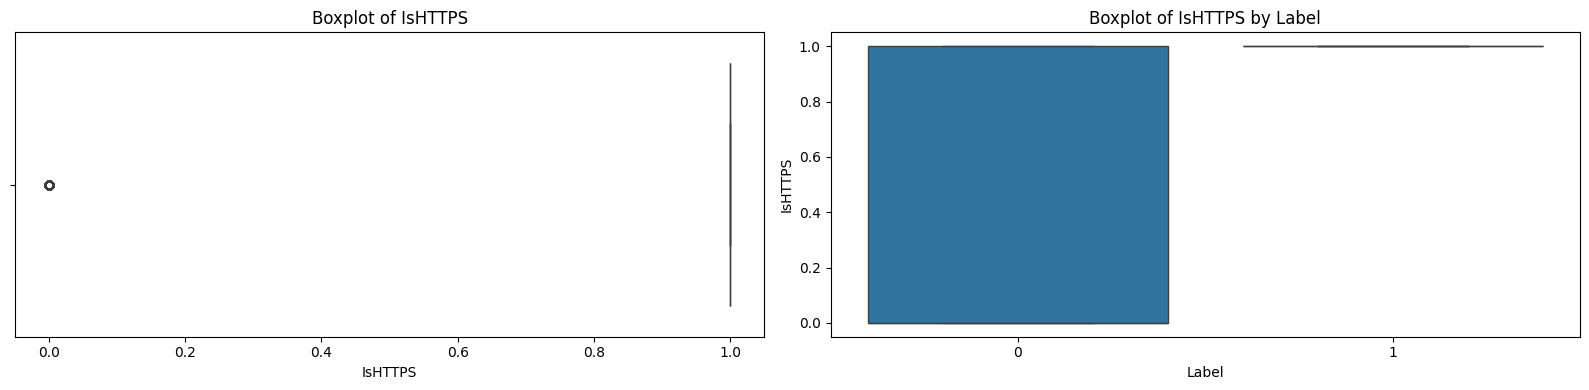

LineOfCode: Q1 18.00, Q3 1277.00, IQR 1259.00, Lower Bound -1870.50, Upper Bound 3165.50, Num Outliers: 19280


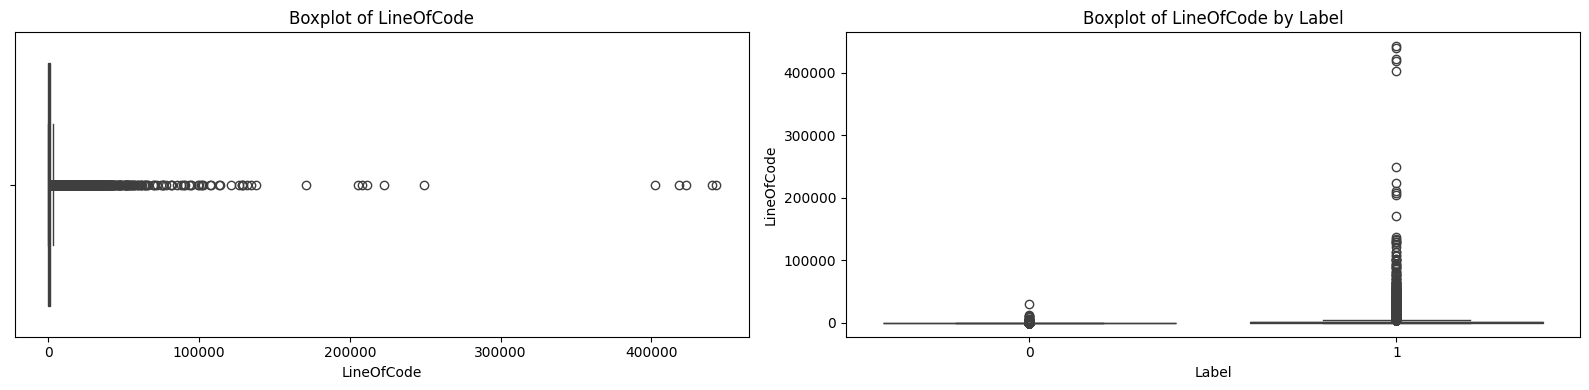

LargestLineLength: Q1 200.00, Q3 8047.00, IQR 7847.00, Lower Bound -11570.50, Upper Bound 19817.50, Num Outliers: 17503


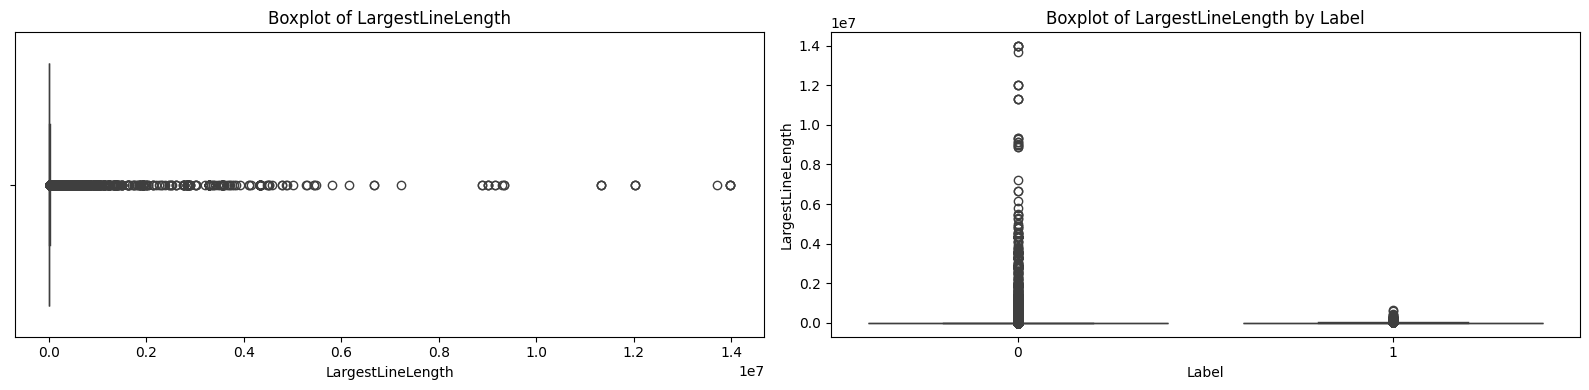

HasTitle: Q1 1.00, Q3 1.00, IQR 0.00, Lower Bound 1.00, Upper Bound 1.00, Num Outliers: 32714


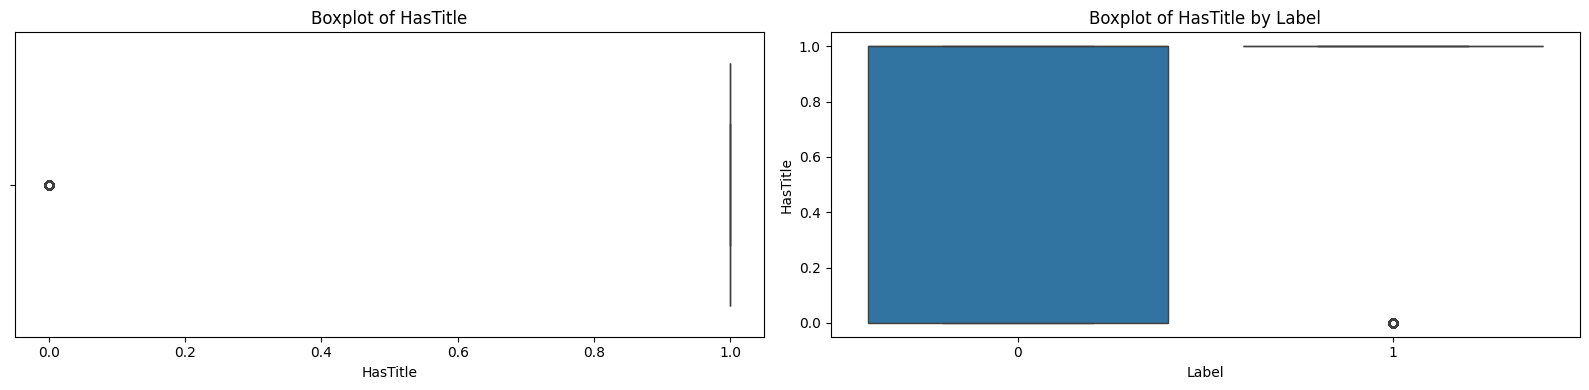

DomainTitleMatchScore: Q1 0.00, Q3 100.00, IQR 100.00, Lower Bound -150.00, Upper Bound 250.00, Num Outliers: 0


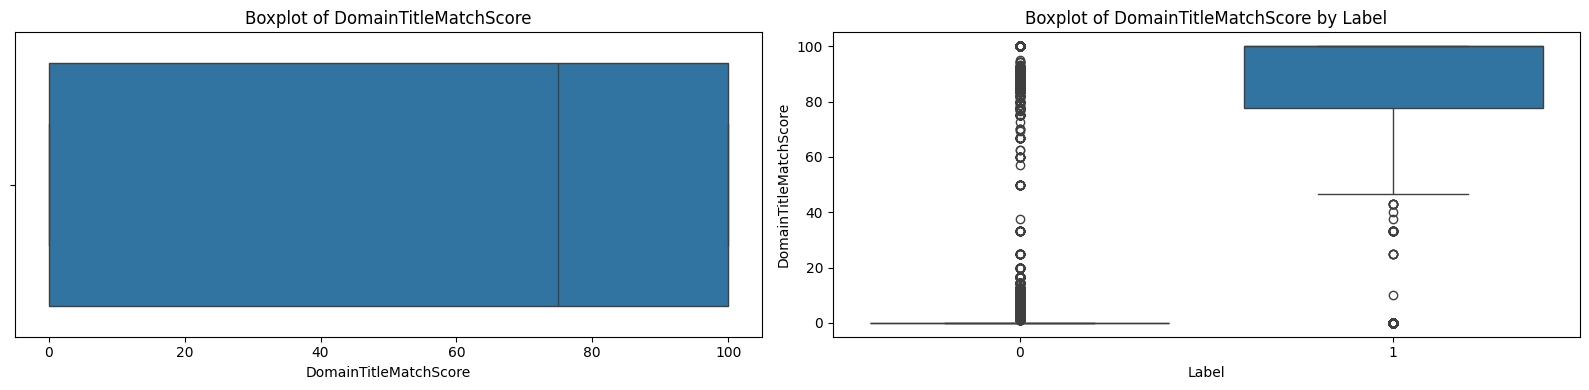

URLTitleMatchScore: Q1 0.00, Q3 100.00, IQR 100.00, Lower Bound -150.00, Upper Bound 250.00, Num Outliers: 0


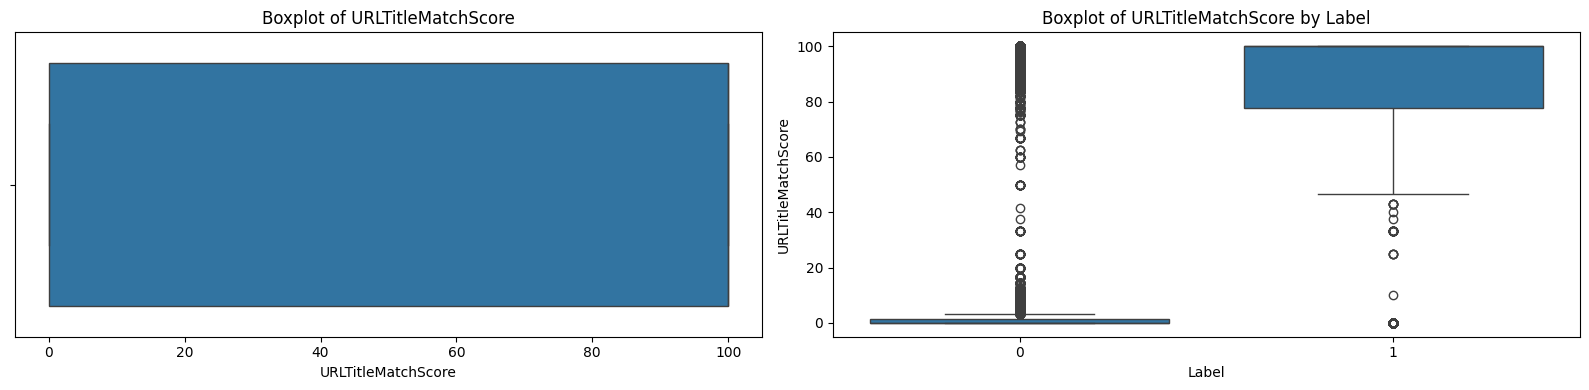

HasFavicon: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


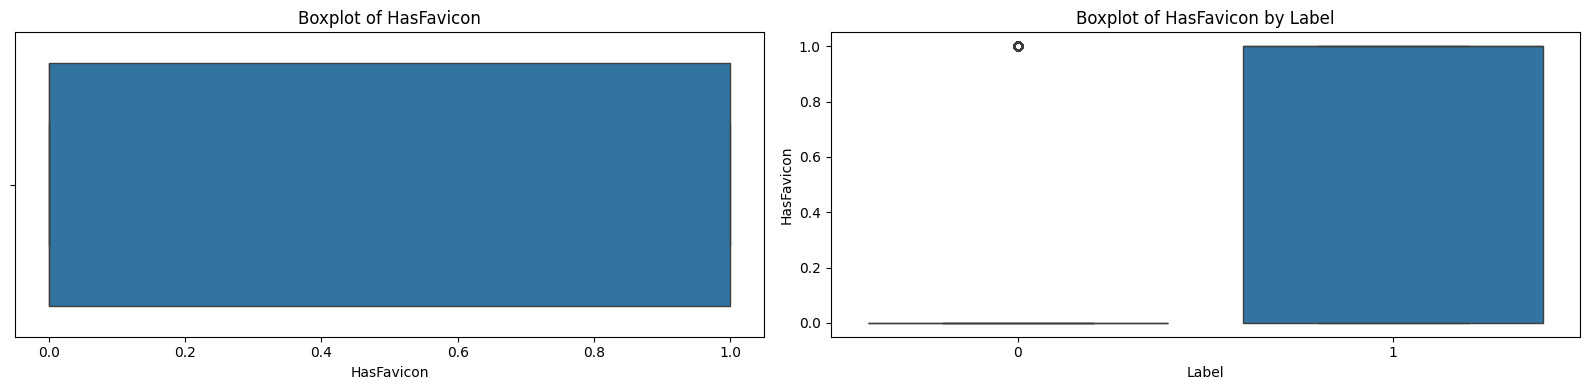

Robots: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


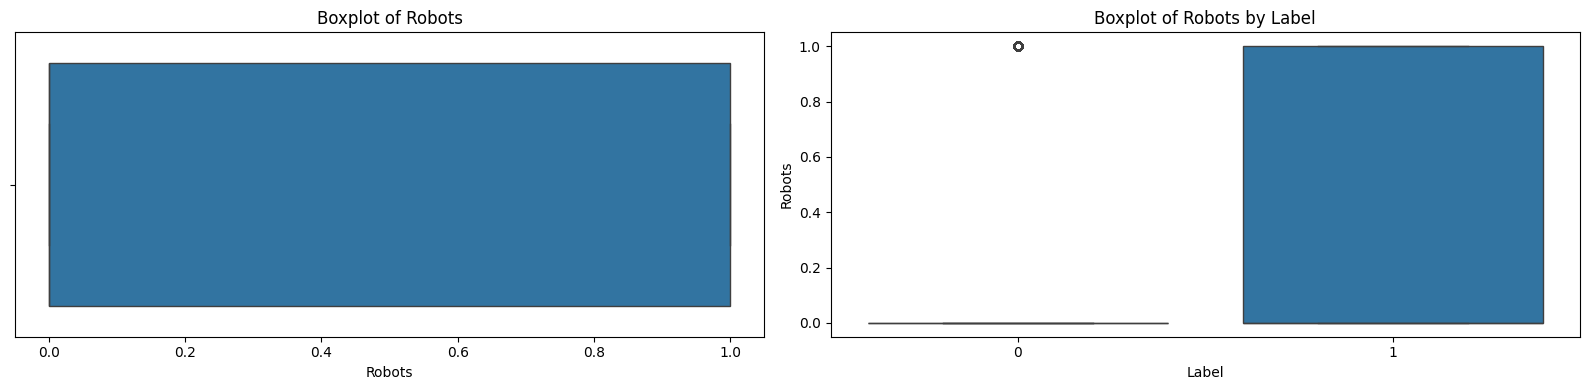

IsResponsive: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


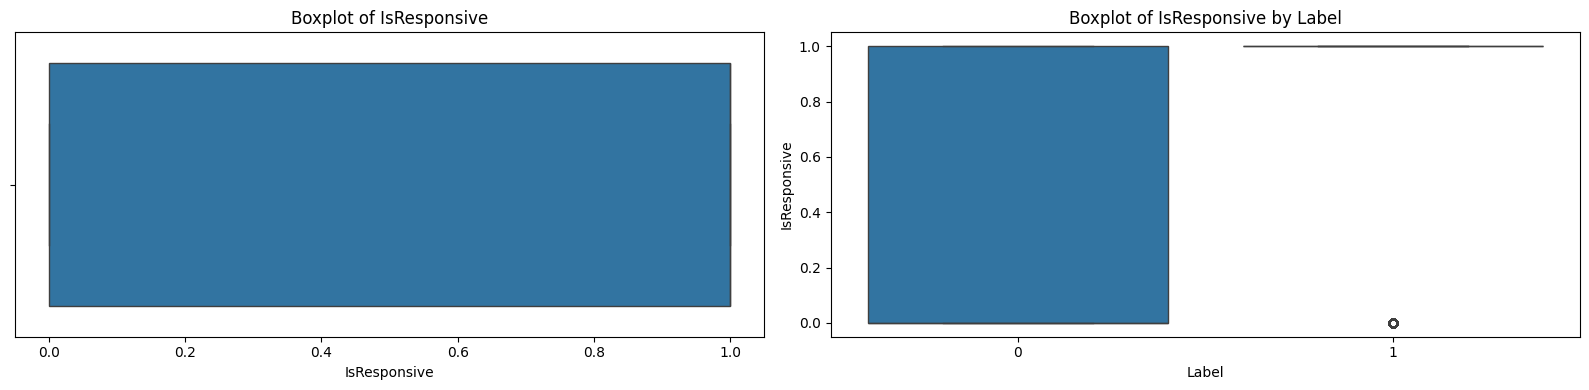

NoOfURLRedirect: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 31464


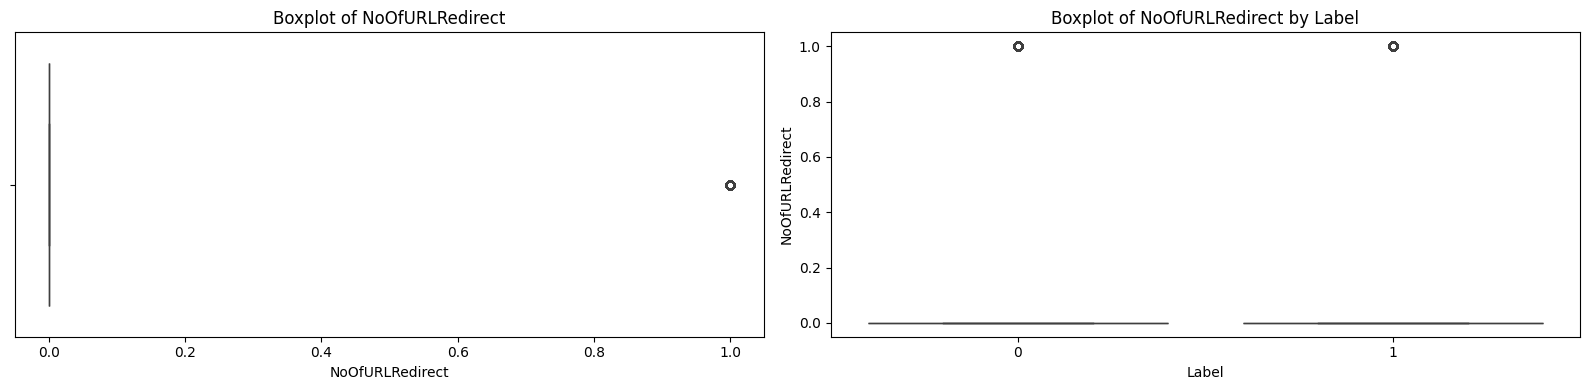

NoOfSelfRedirect: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 9457


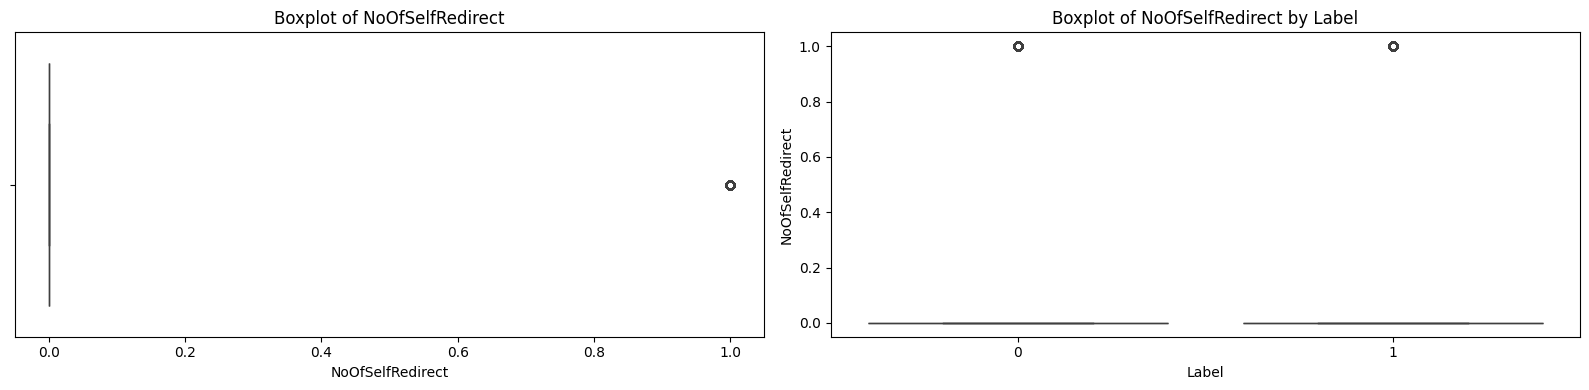

HasDescription: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


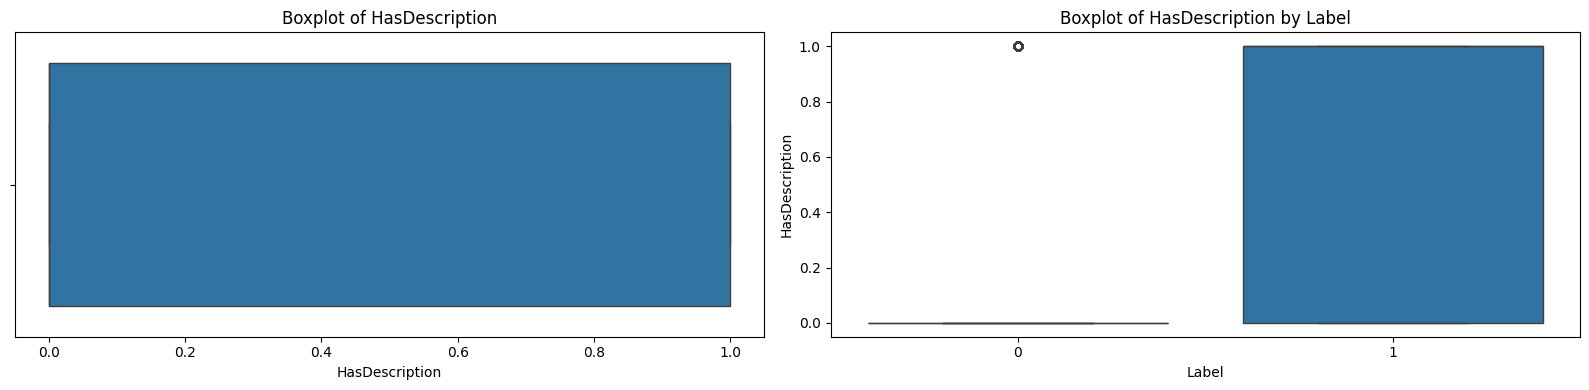

NoOfPopup: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 13411


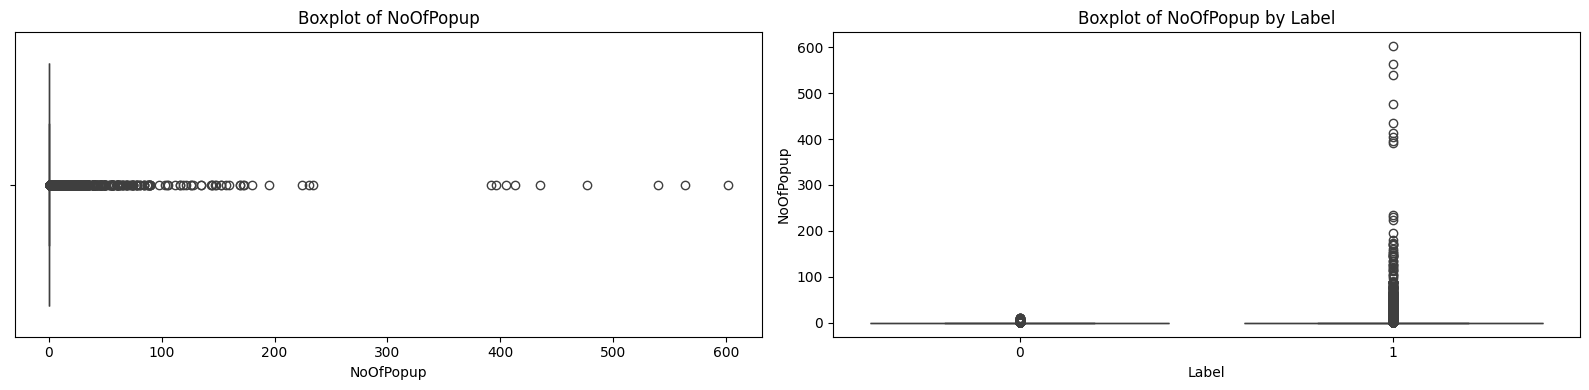

NoOfiFrame: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 34441


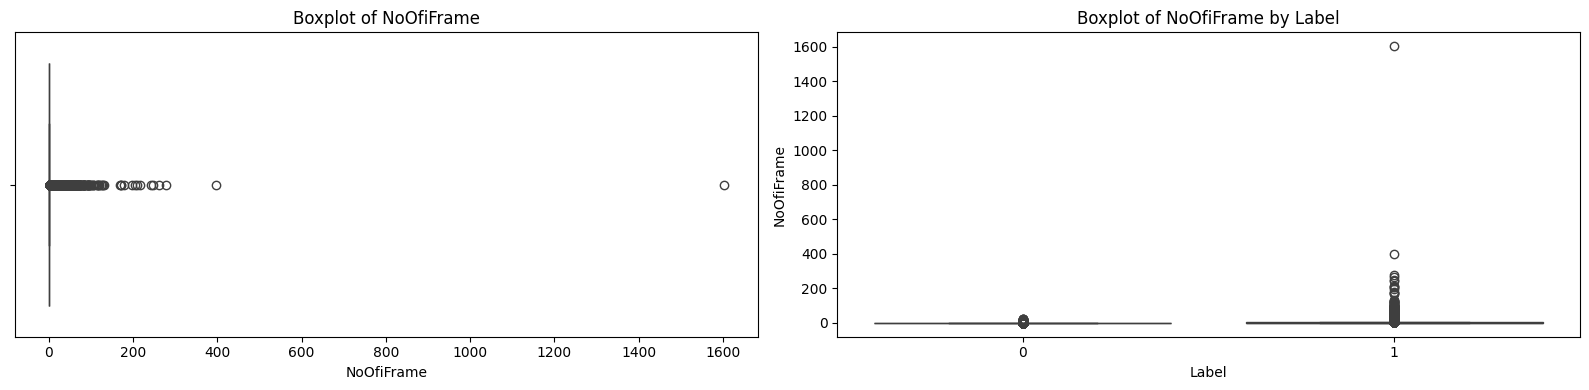

HasExternalFormSubmit: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 10372


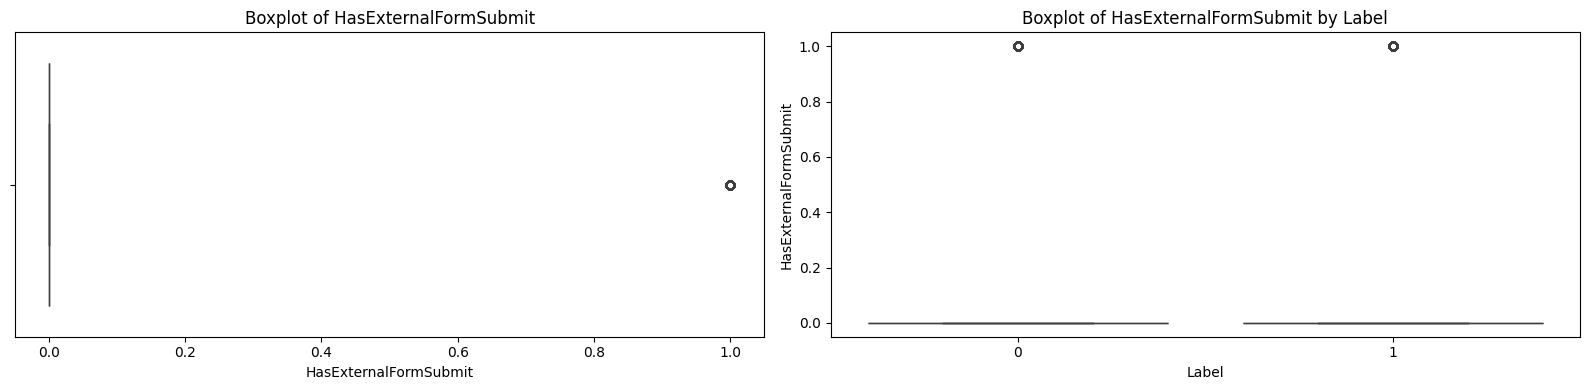

HasSocialNet: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


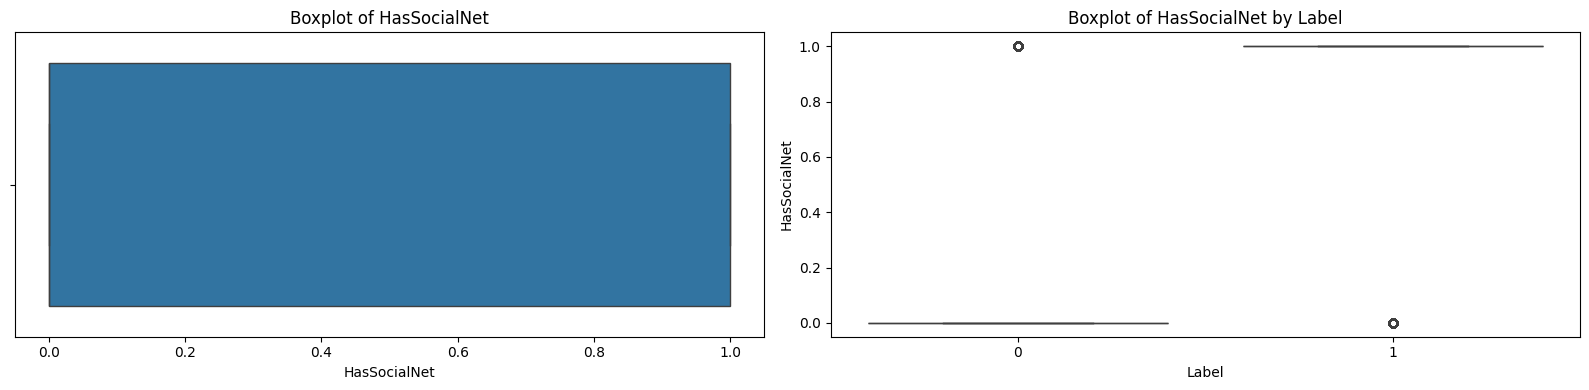

HasSubmitButton: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


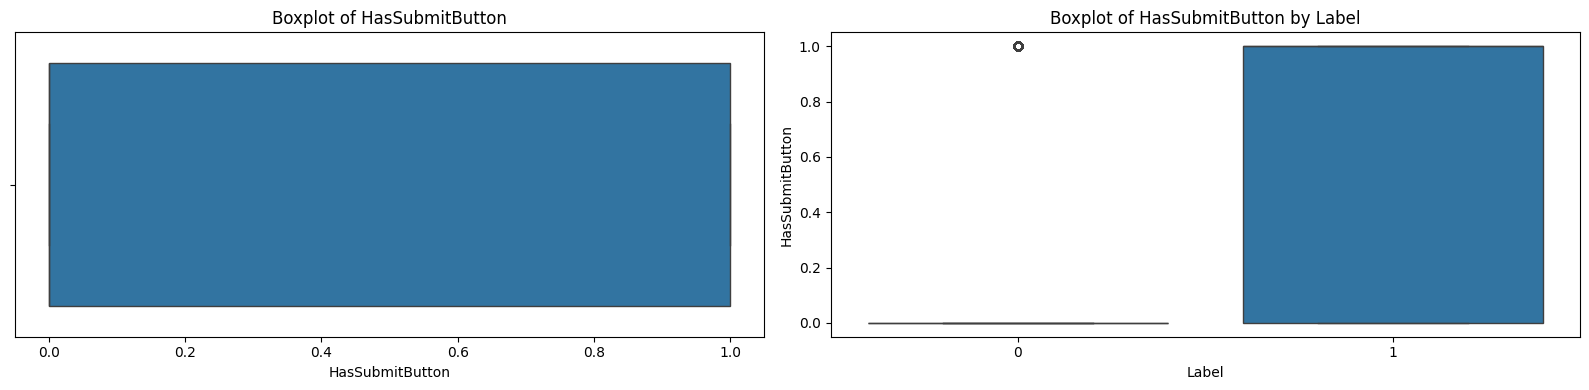

HasHiddenFields: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


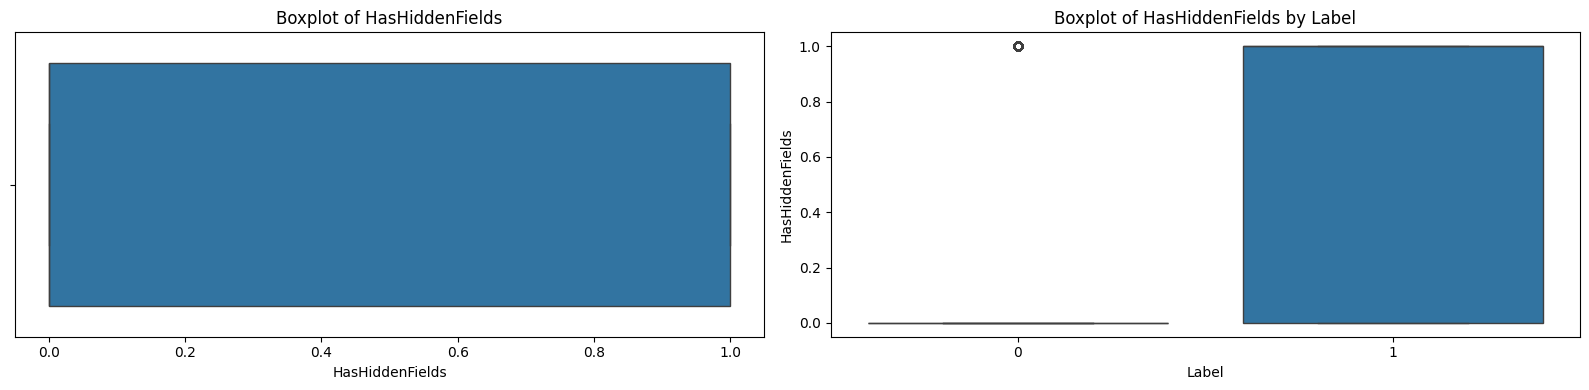

HasPasswordField: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 24113


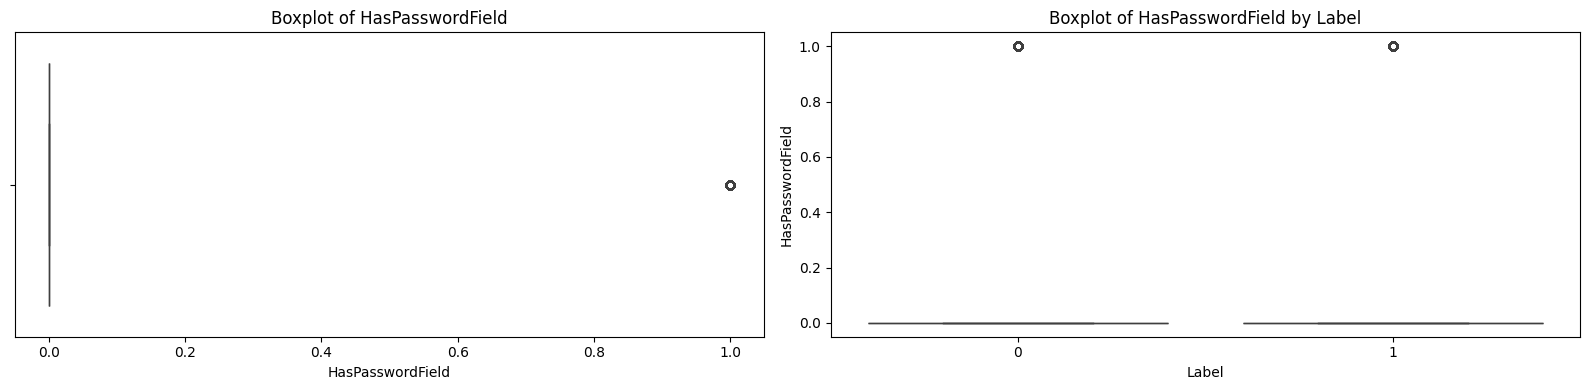

Bank: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 29967


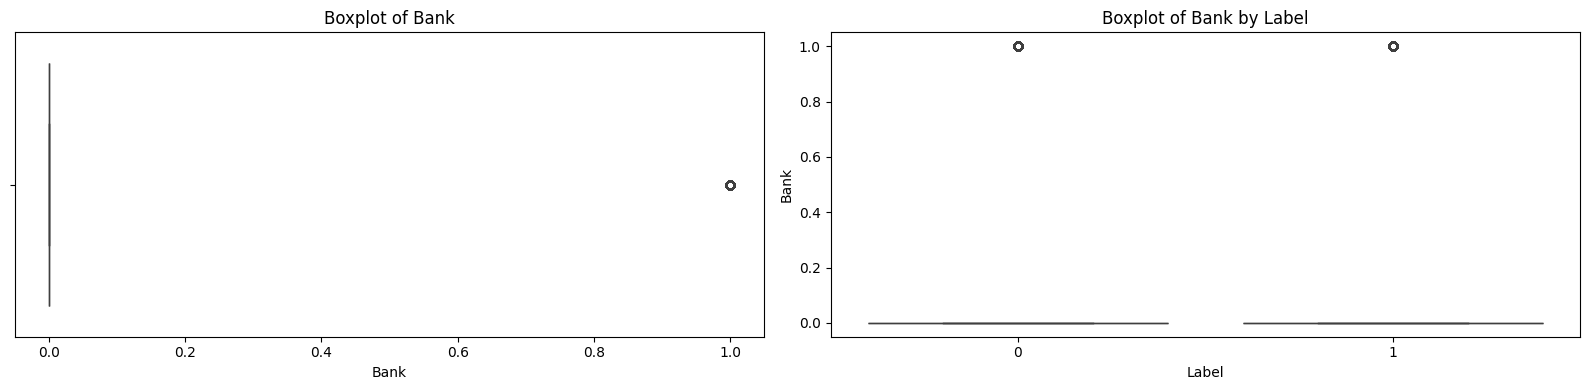

Pay: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 55885


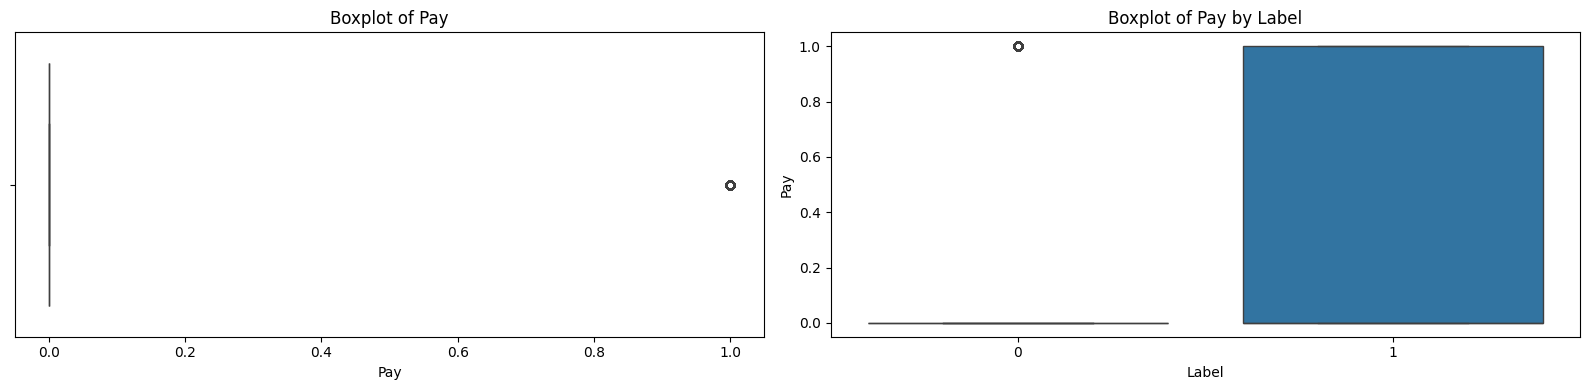

Crypto: Q1 0.00, Q3 0.00, IQR 0.00, Lower Bound 0.00, Upper Bound 0.00, Num Outliers: 5535


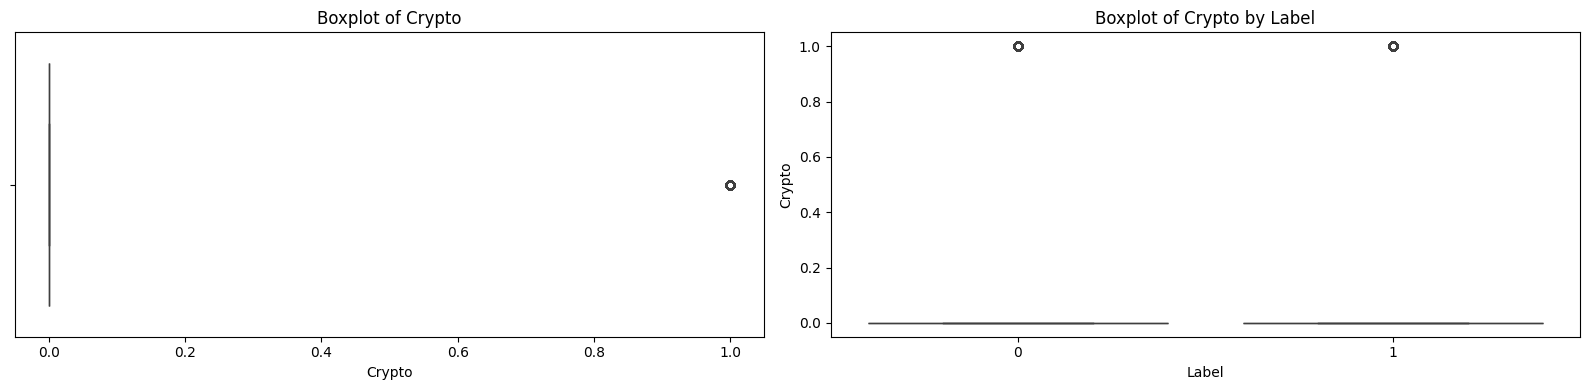

HasCopyrightInfo: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 0


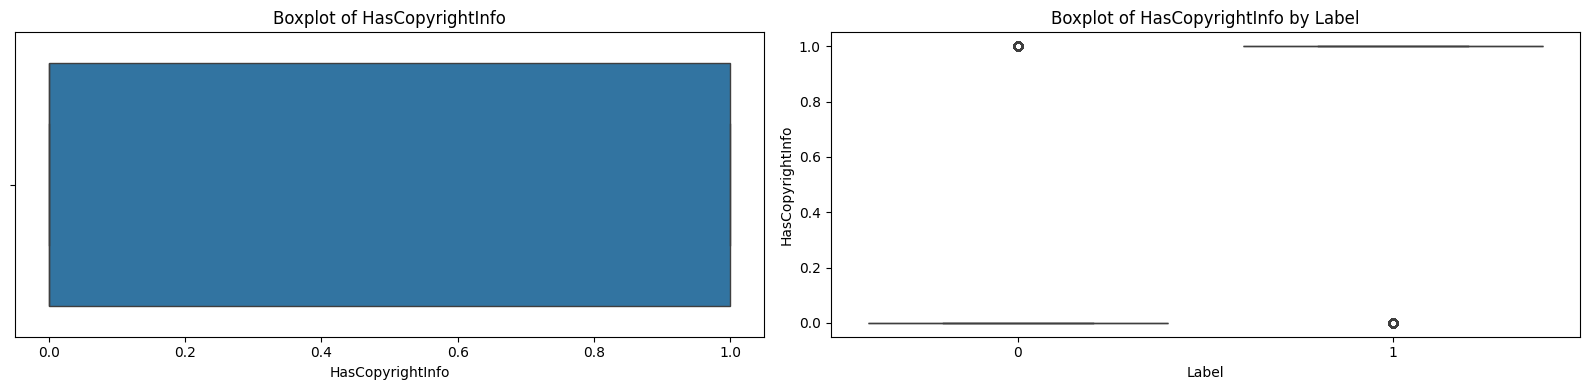

NoOfImage: Q1 0.00, Q3 29.00, IQR 29.00, Lower Bound -43.50, Upper Bound 72.50, Num Outliers: 18362


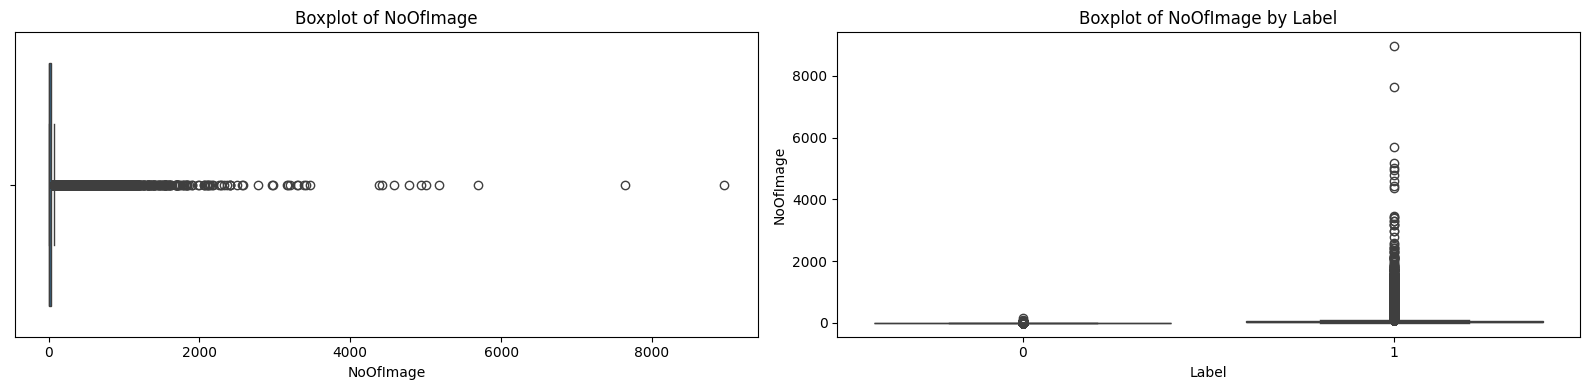

NoOfCSS: Q1 0.00, Q3 8.00, IQR 8.00, Lower Bound -12.00, Upper Bound 20.00, Num Outliers: 17906


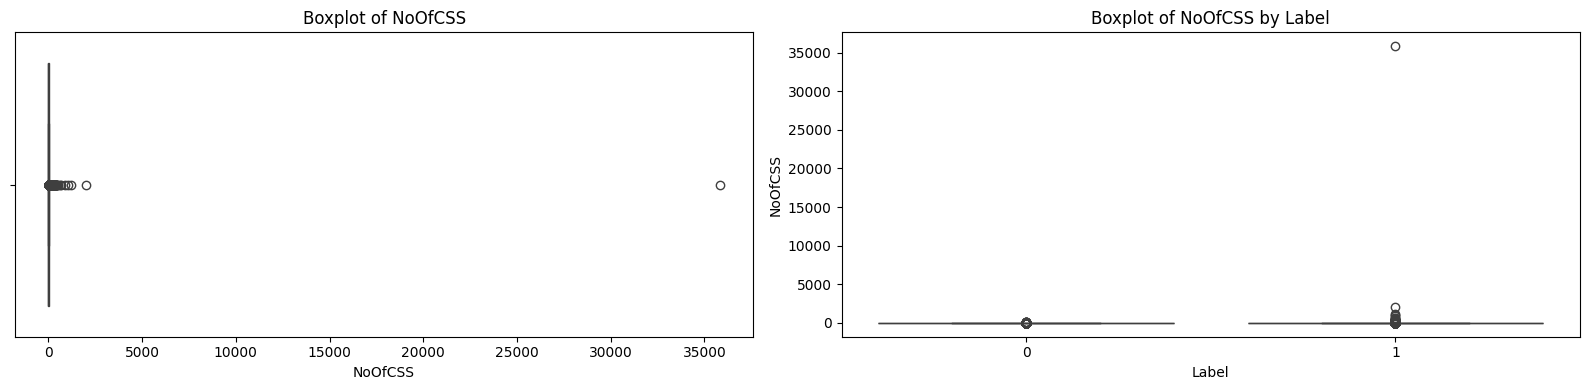

NoOfJS: Q1 0.00, Q3 15.00, IQR 15.00, Lower Bound -22.50, Upper Bound 37.50, Num Outliers: 11852


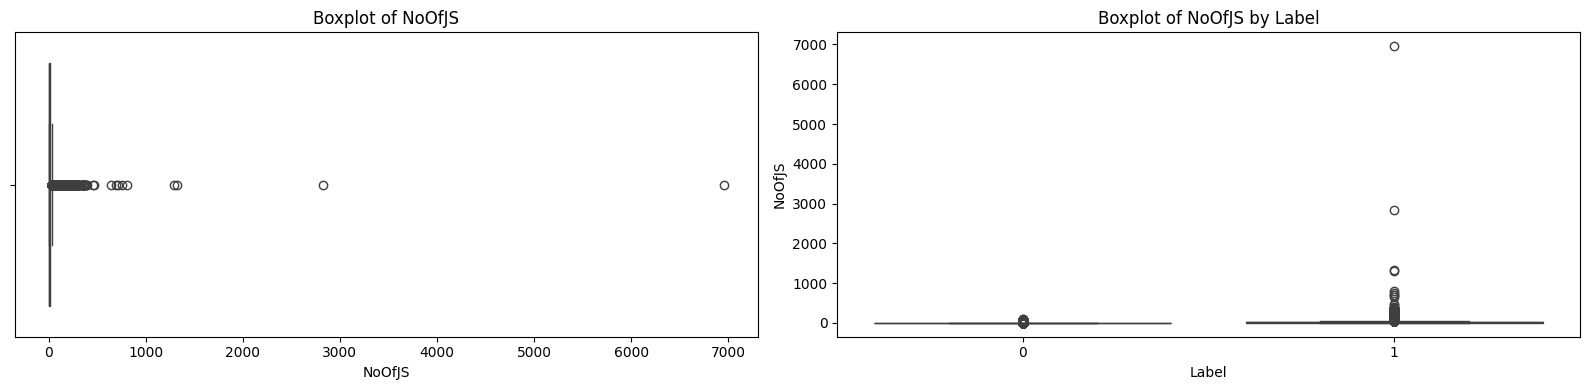

NoOfSelfRef: Q1 0.00, Q3 88.00, IQR 88.00, Lower Bound -132.00, Upper Bound 220.00, Num Outliers: 15576


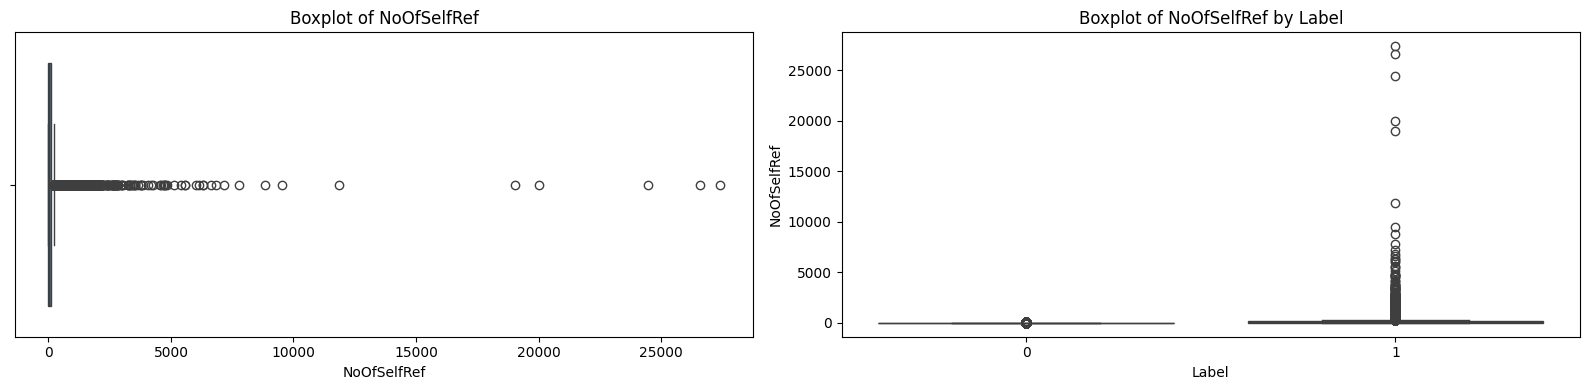

NoOfEmptyRef: Q1 0.00, Q3 1.00, IQR 1.00, Lower Bound -1.50, Upper Bound 2.50, Num Outliers: 38885


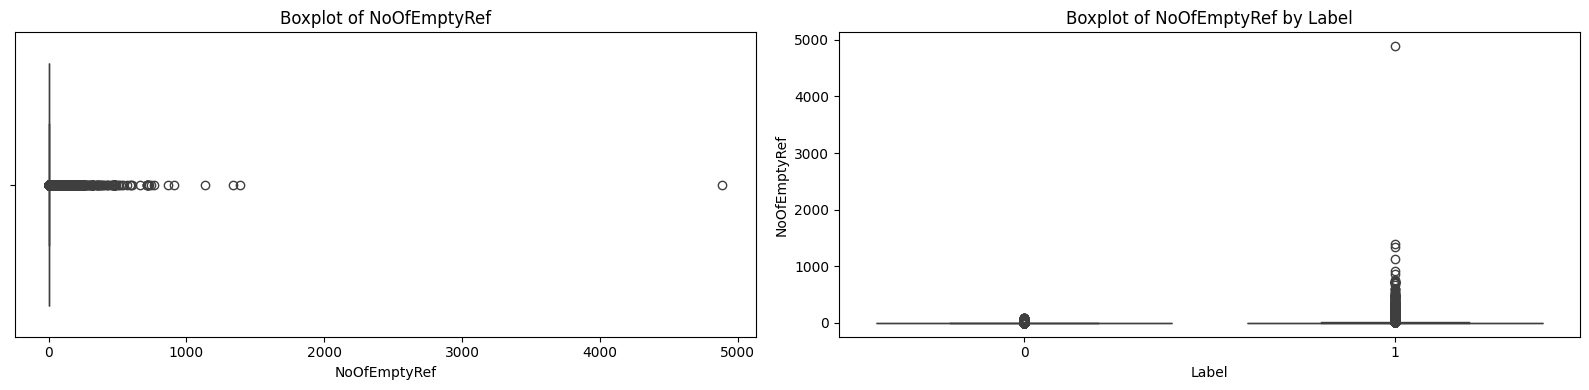

NoOfExternalRef: Q1 1.00, Q3 57.00, IQR 56.00, Lower Bound -83.00, Upper Bound 141.00, Num Outliers: 22780


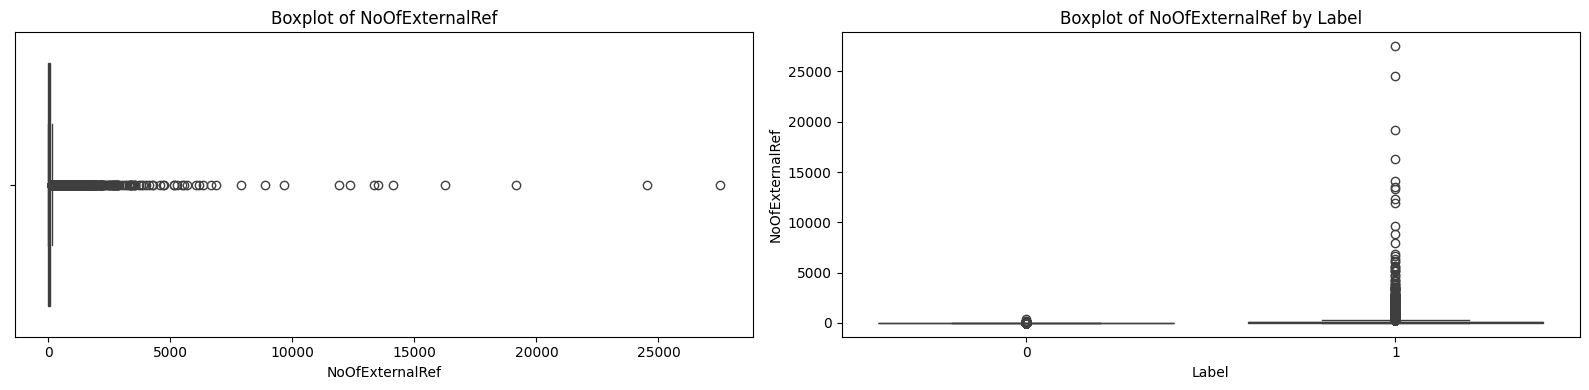

In [ ]:
for n in numeric_df.columns:
    Q1 = numeric_df[n].quantile(0.25)
    Q3 = numeric_df[n].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = numeric_df[(numeric_df[n] < lower_bound) | (numeric_df[n] > upper_bound)]
    print(f"{n}: Q1 {Q1:.2f}, Q3 {Q3:.2f}, IQR {IQR:.2f}, Lower Bound {lower_bound:.2f}, Upper Bound {upper_bound:.2f}, Num Outliers: {len(outliers)}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 4)) # 2 horizontal subplots

    # Boxplot of the numeric feature (1 variable)
    sns.boxplot(x=numeric_df[n], ax=axes[0])
    axes[0].set_title(f"Boxplot of {n}")
    axes[0].set_xlabel(n)

    # Boxplot of the numeric feature by Label (2 variables)
    sns.boxplot(x=y['label'], y=numeric_df[n], ax=axes[1])
    axes[1].set_title(f"Boxplot of {n} by Label")
    axes[1].set_xlabel("Label")
    axes[1].set_ylabel(n)

    plt.tight_layout()
    plt.show()
print()

# KDE (Kernel Density Estimation) Plot

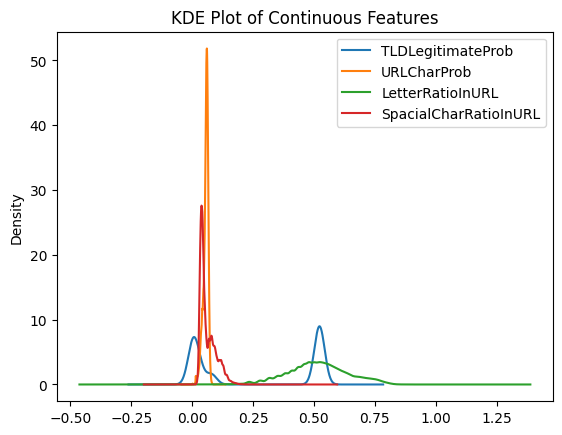

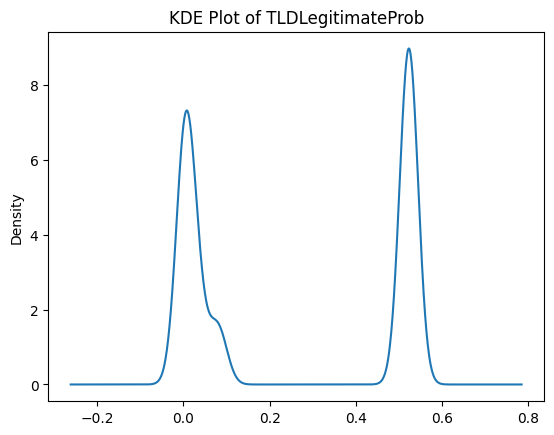

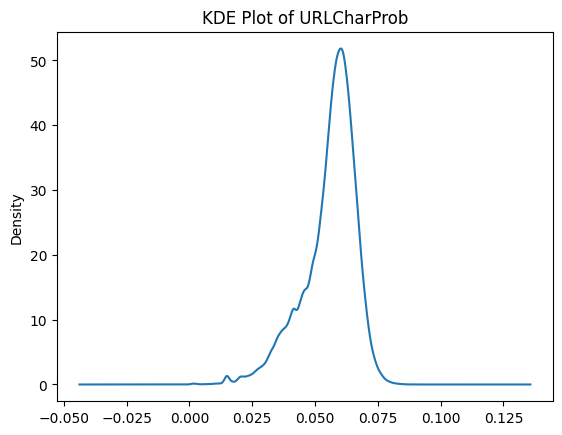

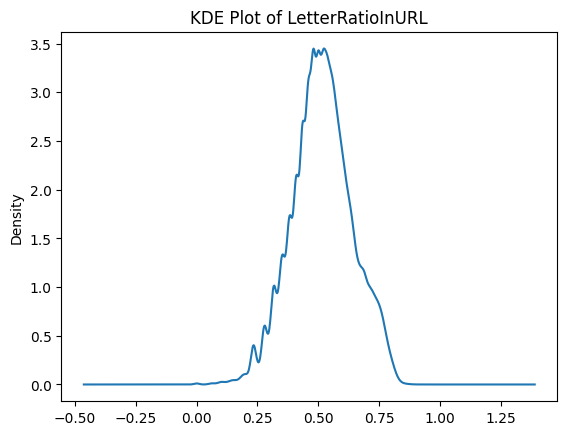

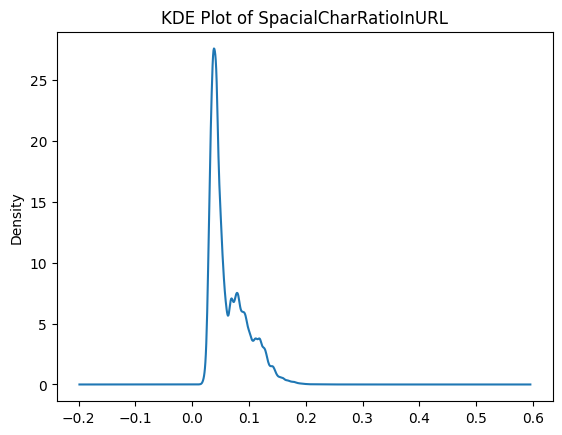

In [ ]:
df[['TLDLegitimateProb', 'URLCharProb', 'LetterRatioInURL', 'SpacialCharRatioInURL']].plot(kind = 'kde')

plt.title("KDE Plot of Continuous Features")
plt.show()

features = ['TLDLegitimateProb', 'URLCharProb', 'LetterRatioInURL', 'SpacialCharRatioInURL']

for item in features:
  df[item].plot(kind = 'kde')

  plt.title("KDE Plot of " + item)
  plt.show()

# Hexbin Plot

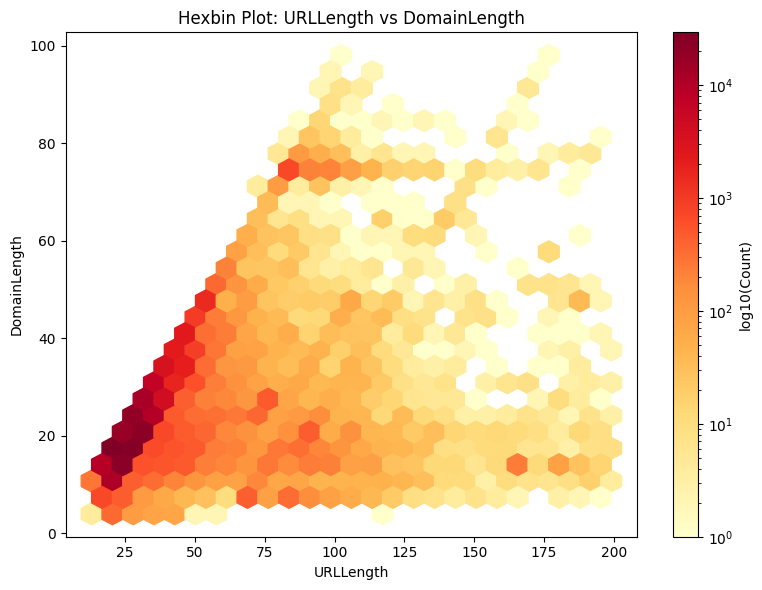

In [ ]:
df_plot = df[(df['URLLength'] < 200) & (df['DomainLength'] < 100)]

fig, ax = plt.subplots(figsize=(8, 6))

hb = ax.hexbin(
    df_plot['URLLength'],
    df_plot['DomainLength'],
    gridsize=25,
    cmap='YlOrRd',
    mincnt=1,
    bins='log'
)

cb = fig.colorbar(hb, ax=ax)
cb.set_label('log10(Count)')

ax.set_xlabel('URLLength')
ax.set_ylabel('DomainLength')
ax.set_title('Hexbin Plot: URLLength vs DomainLength')

plt.tight_layout()
plt.show()

Area Plot

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo



# Load dataset directly from UCI thank you for teaching me apples
dataset = fetch_ucirepo(id = 967)

df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)

numeric_df = df.select_dtypes(include='number')

area_df = numeric_df[['URLLength','DomainLength','NoOfSubDomain']].head(200)
area_df.plot.area(alpha=0.6)

plt.title("Area plot of selected URL features")
plt.xlabel("Index")
plt.ylabel("Values")
plt.show()


ModuleNotFoundError: No module named 'ucimlrepo'

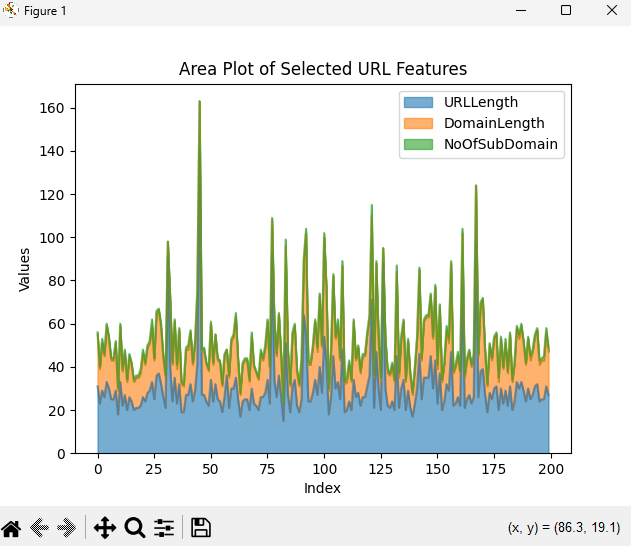

**Scatter Plot **

In [ ]:
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo
import pandas as pd


dataset = fetch_ucirepo(id=967)
df = dataset.data.features

plt.scatter(df['URLLength'], df[' DomainLength'])

plt.title("Scatter Plot of URLLength vs DomainLength")
plt.xlabel("URLLength")
plt.ylabel("DomainLength   ")
plt.show()

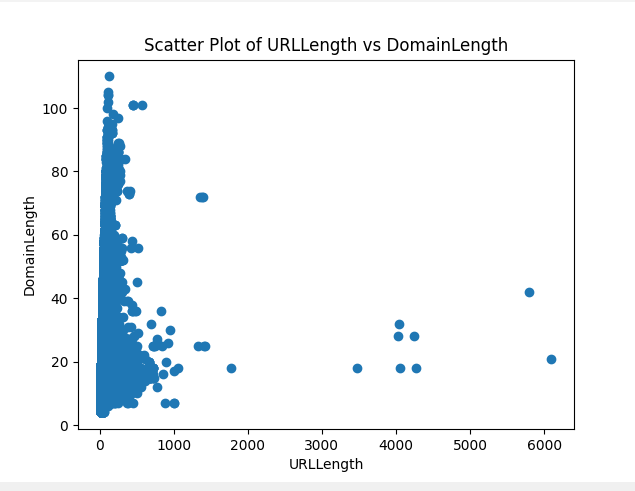

# Correlation Matrix Plot (Heat Map)

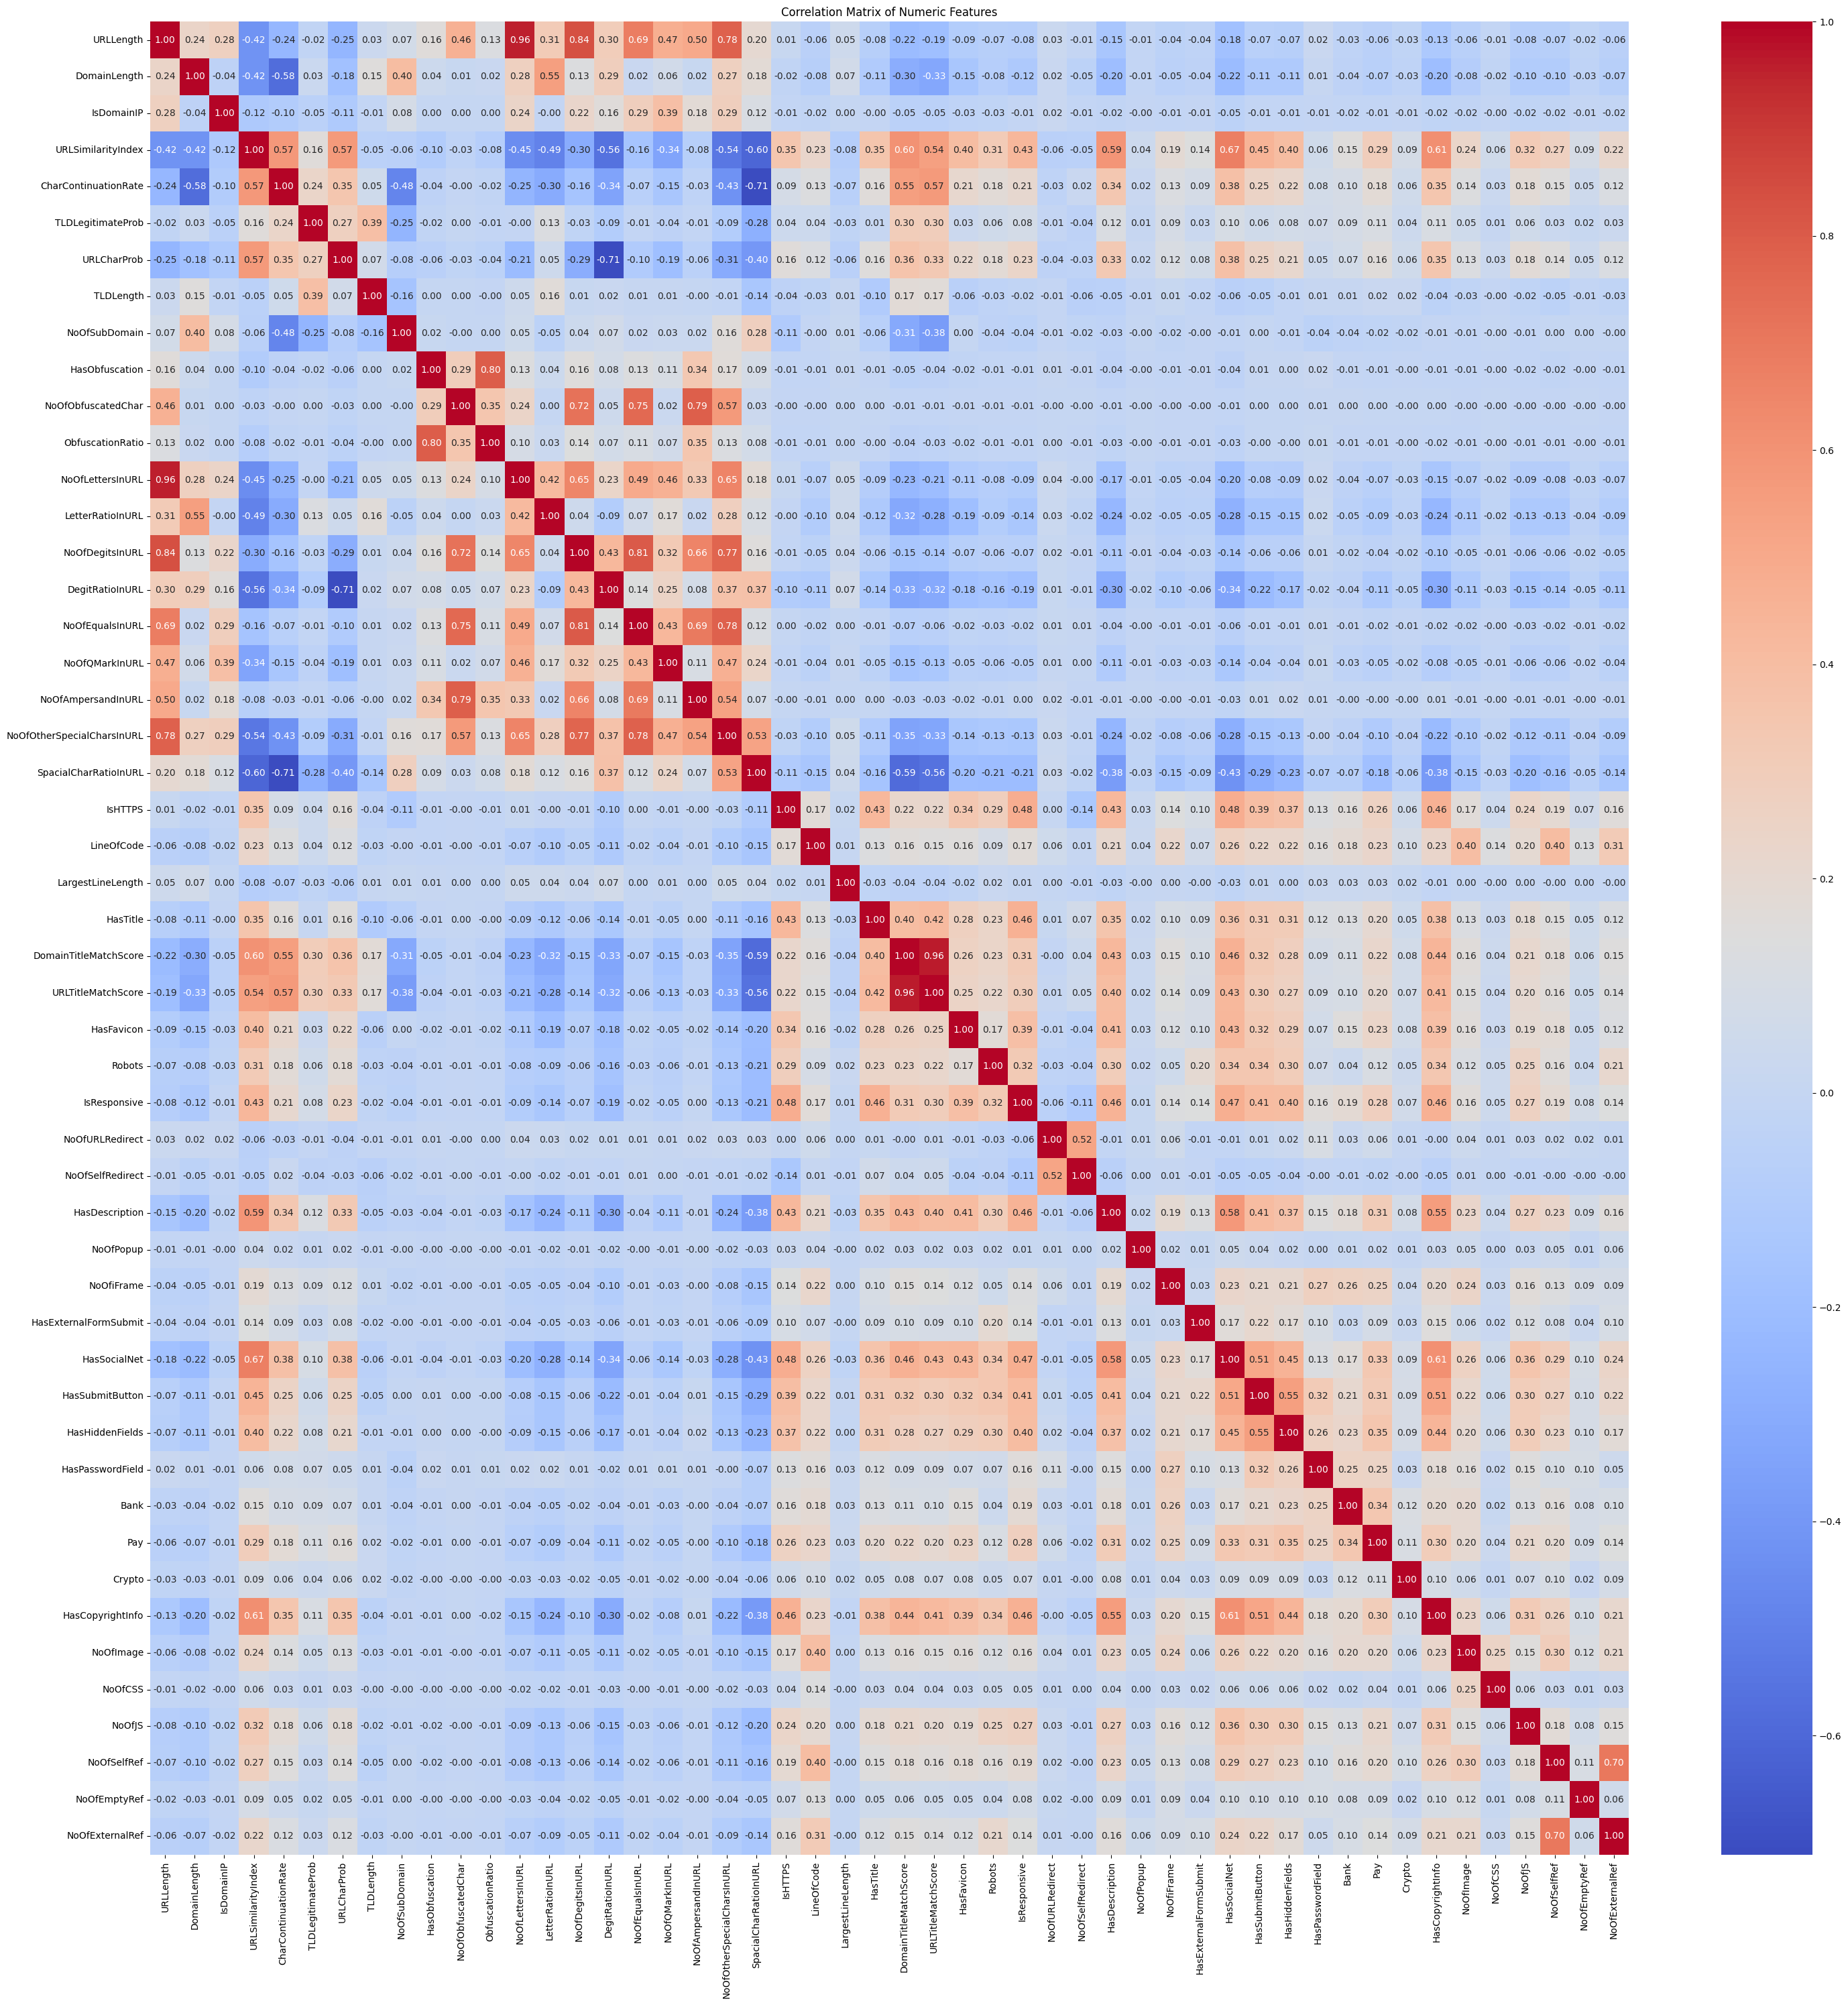

In [ ]:
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(30, 30))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numeric Features')
plt.tight_layout()
plt.show()

In [ ]:
correlation_pairs = correlation_matrix.unstack()
sorted_pairs = correlation_pairs.sort_values(ascending=False, key=abs)

strongest_correlations = []
processed_pairs = set()

for (col1, col2), corr_value in sorted_pairs.items():
    if col1 != col2 and frozenset([col1, col2]) not in processed_pairs:
        strongest_correlations.append(f"{col1}, {col2}: {corr_value:.4f}")
        processed_pairs.add(frozenset([col1, col2]))

# display top correlations
print("Top correlations (absolute value):")
for corr_str in strongest_correlations[:30]:
    print(corr_str)

Top correlations (absolute value):
DomainTitleMatchScore, URLTitleMatchScore: 0.9610
URLLength, NoOfLettersInURL: 0.9560
NoOfDegitsInURL, URLLength: 0.8358
NoOfEqualsInURL, NoOfDegitsInURL: 0.8060
ObfuscationRatio, HasObfuscation: 0.7988
NoOfObfuscatedChar, NoOfAmpersandInURL: 0.7865
NoOfEqualsInURL, NoOfOtherSpecialCharsInURL: 0.7847
URLLength, NoOfOtherSpecialCharsInURL: 0.7826
NoOfDegitsInURL, NoOfOtherSpecialCharsInURL: 0.7675
NoOfObfuscatedChar, NoOfEqualsInURL: 0.7545
NoOfDegitsInURL, NoOfObfuscatedChar: 0.7212
SpacialCharRatioInURL, CharContinuationRate: -0.7110
URLCharProb, DegitRatioInURL: -0.7089
NoOfSelfRef, NoOfExternalRef: 0.7007
NoOfEqualsInURL, NoOfAmpersandInURL: 0.6950
NoOfEqualsInURL, URLLength: 0.6851
URLSimilarityIndex, HasSocialNet: 0.6737
NoOfDegitsInURL, NoOfAmpersandInURL: 0.6575
NoOfLettersInURL, NoOfOtherSpecialCharsInURL: 0.6525
NoOfLettersInURL, NoOfDegitsInURL: 0.6480
HasCopyrightInfo, URLSimilarityIndex: 0.6136
HasCopyrightInfo, HasSocialNet: 0.6075
URLSim